In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
def clean_fred_data(file_path, value_col_name):
    df = pd.read_csv(file_path)
    # Automatically find the date column
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    # Convert all columns to numeric
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    # Resample to quarterly
    df_q = df_numeric.resample('QE').mean()
    df_q.columns = [value_col_name]
    return df_q

In [4]:
# historical data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')  # Added charge-off data
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')

df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge, df_gdp], axis=1).dropna()


In [5]:
#check stationarity
df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
df_history = df_history.dropna()

print(df_history.head())

                  Loans_Billions         CPI  Unemployment_Rate  \
observation_date                                                  
1986-03-31            502.374267  109.566667           7.033333   
1986-06-30            508.855633  109.033333           7.166667   
1986-09-30            515.118767  109.700000           6.966667   
1986-12-31            526.926900  110.466667           6.833333   
1987-03-31            548.151267  111.800000           6.600000   

                  Chargeoff_Rate       GDP  Loan_Growth  Inflation  
observation_date                                                    
1986-03-31                  1.46  8749.127     5.441802   3.105395  
1986-06-30                  1.47  8788.524     5.876495   1.678583  
1986-09-30                  1.56  8872.601     5.060920   1.668211  
1986-12-31                  1.48  8920.193     6.140820   1.345566  
1987-03-31                  1.27  8986.367     9.112131   2.038333  


In [6]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

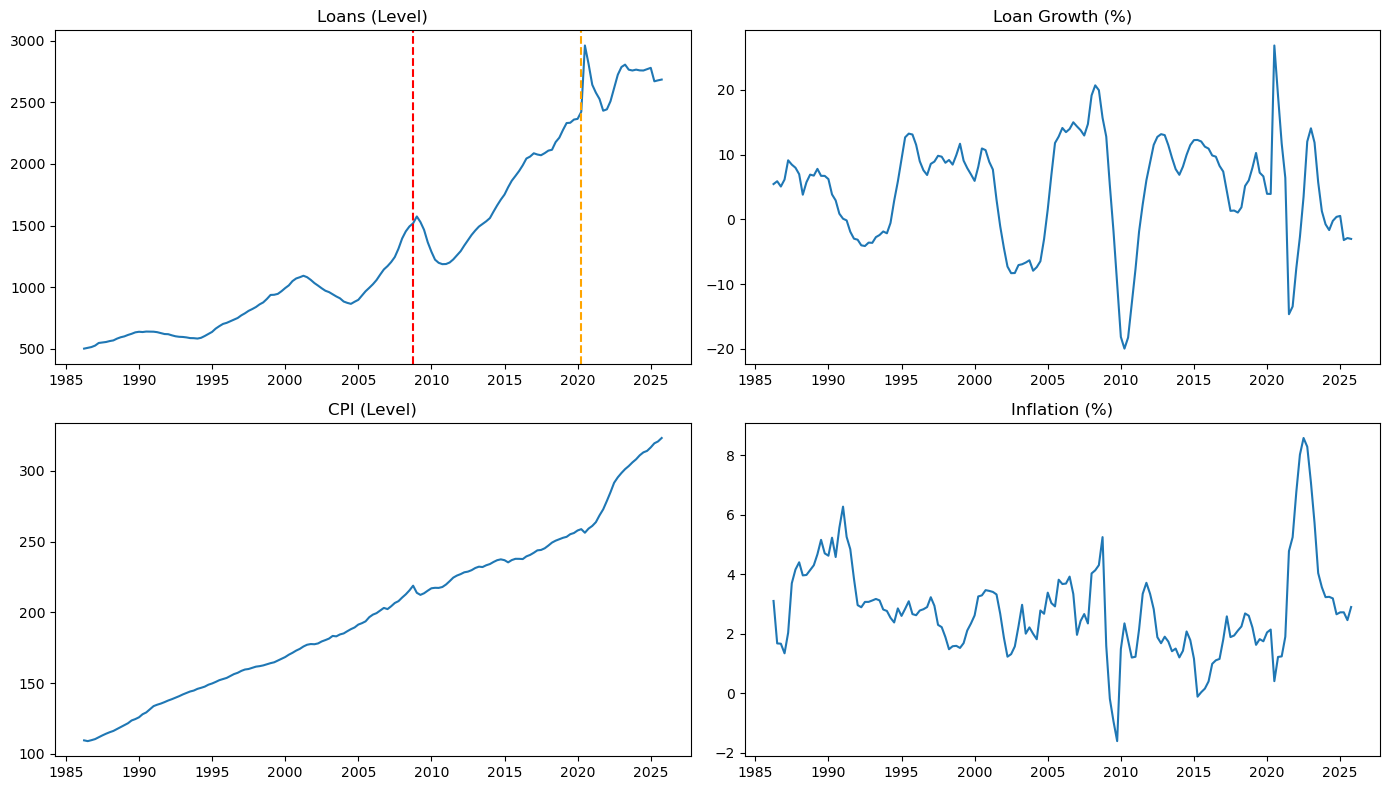

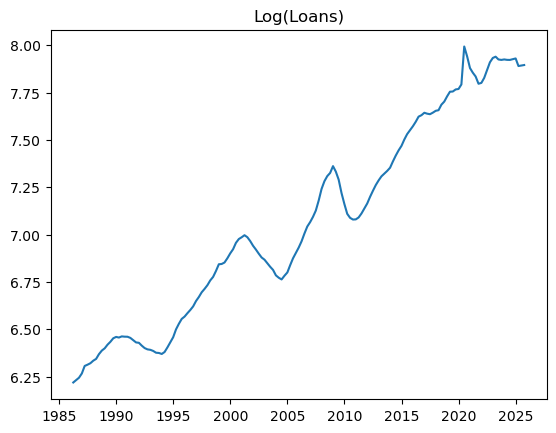

In [7]:
df = df_history.copy()

# -----------------------------
# 1️⃣ Plot the Data First
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,8))

# Loans
axes[0,0].plot(df.index, df['Loans_Billions'])
axes[0,0].set_title('Loans (Level)')
axes[0,0].axvline(pd.to_datetime('2008-09-30'), color='red', linestyle='--')  # 2008 Crisis
axes[0,0].axvline(pd.to_datetime('2020-03-31'), color='orange', linestyle='--') # COVID

# Loan growth
axes[0,1].plot(df.index, df['Loan_Growth'])
axes[0,1].set_title('Loan Growth (%)')

# CPI & Inflation
axes[1,0].plot(df.index, df['CPI'])
axes[1,0].set_title('CPI (Level)')

axes[1,1].plot(df.index, df['Inflation'])
axes[1,1].set_title('Inflation (%)')

plt.tight_layout()
plt.show()

# Optional: log-transform check
df['Loans_log'] = np.log(df['Loans_Billions'])
plt.plot(df.index, df['Loans_log'])
plt.title('Log(Loans)')
plt.show()

In [8]:
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Optional: log-transform Loans
df_history['Log_Loans'] = np.log(df_history['Loans_Billions'])

# Columns to test
cols_to_test = ['Log_Loans', 'Loan_Growth', 'Inflation', 'Chargeoff_Rate', 'Unemployment_Rate', 'GDP']

# Function to run ADF test
def adf_summary(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic = {result[0]:.4f}")
    print(f"  p-value = {result[1]:.4f}")
    print(f"  # Lags Used = {result[2]}")
    print(f"  # Observations = {result[3]}")
    print(f"  Critical Values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-"*40)

# Run tests
for col in cols_to_test:
    adf_summary(df_history[col], col)

ADF Test for Log_Loans:
  Test Statistic = -0.6026
  p-value = 0.8704
  # Lags Used = 1
  # Observations = 157
  Critical Values:
    1%: -3.4727
    5%: -2.8801
    10%: -2.5767
----------------------------------------
ADF Test for Loan_Growth:
  Test Statistic = -4.2975
  p-value = 0.0004
  # Lags Used = 14
  # Observations = 144
  Critical Values:
    1%: -3.4766
    5%: -2.8818
    10%: -2.5776
----------------------------------------
ADF Test for Inflation:
  Test Statistic = -2.1350
  p-value = 0.2307
  # Lags Used = 12
  # Observations = 146
  Critical Values:
    1%: -3.4760
    5%: -2.8815
    10%: -2.5774
----------------------------------------
ADF Test for Chargeoff_Rate:
  Test Statistic = -3.6837
  p-value = 0.0043
  # Lags Used = 3
  # Observations = 155
  Critical Values:
    1%: -3.4733
    5%: -2.8804
    10%: -2.5768
----------------------------------------
ADF Test for Unemployment_Rate:
  Test Statistic = -3.3587
  p-value = 0.0125
  # Lags Used = 0
  # Observation

In [9]:
# Check exact column names
print(df_history.columns.tolist())

['Loans_Billions', 'CPI', 'Unemployment_Rate', 'Chargeoff_Rate', 'GDP', 'Loan_Growth', 'Inflation', 'Log_Loans']


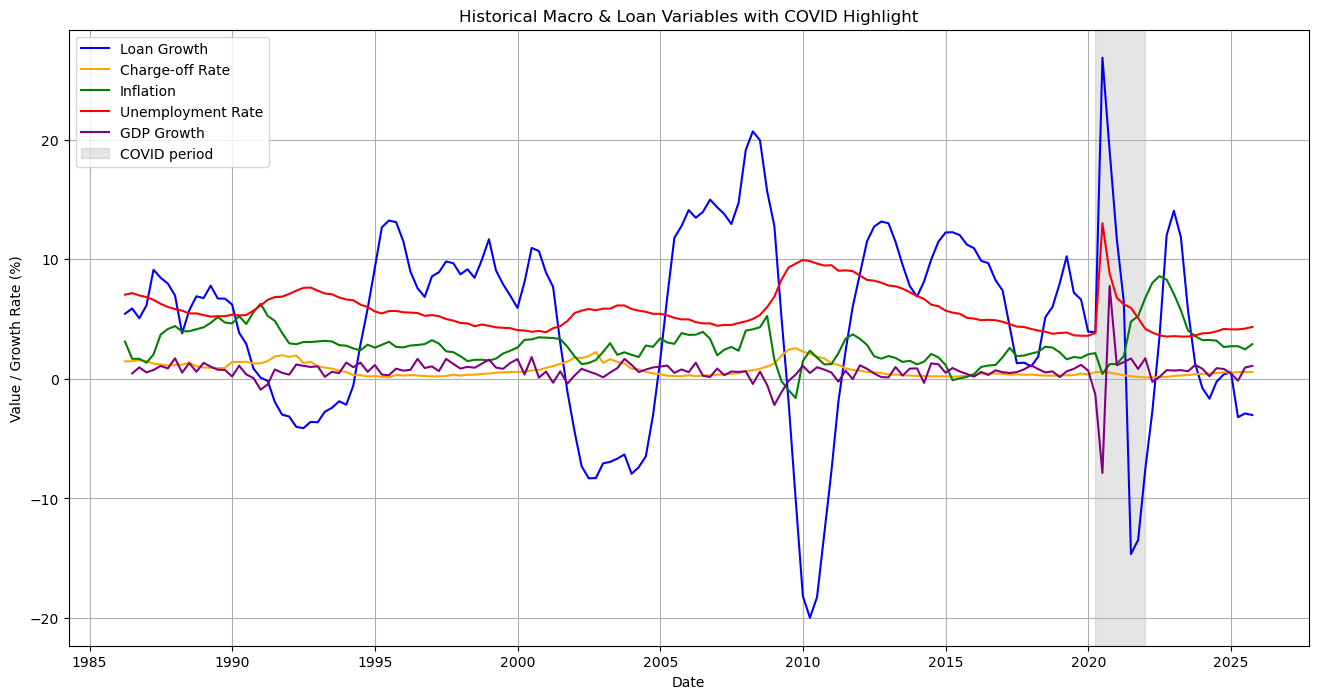

In [10]:
import matplotlib.pyplot as plt

# Make sure 'observation_date' is the index
df_plot = df_history.copy()
df_plot.index = pd.to_datetime(df_plot.index)

# Compute GDP growth rate (quarter-over-quarter, in %)
df_plot['GDP_Growth'] = df_plot['GDP'].pct_change() * 100

# Set up figure
plt.figure(figsize=(16, 8))

# Plot Loan Growth
plt.plot(df_plot.index, df_plot['Loan_Growth'], label='Loan Growth', color='blue')

# Plot Charge-off Rate
plt.plot(df_plot.index, df_plot['Chargeoff_Rate'], label='Charge-off Rate', color='orange')

# Plot Inflation
plt.plot(df_plot.index, df_plot['Inflation'], label='Inflation', color='green')

# Plot Unemployment Rate
plt.plot(df_plot.index, df_plot['Unemployment_Rate'], label='Unemployment Rate', color='red')

# Plot GDP Growth
plt.plot(df_plot.index, df_plot['GDP_Growth'], label='GDP Growth', color='purple')

# Highlight potential COVID period (2020 Q1 to 2021 Q4)
plt.axvspan(pd.to_datetime('2020-03-31'), pd.to_datetime('2021-12-31'), color='gray', alpha=0.2, label='COVID period')

# Labels & legend
plt.title('Historical Macro & Loan Variables with COVID Highlight')
plt.xlabel('Date')
plt.ylabel('Value / Growth Rate (%)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [11]:
# Define COVID period (quarterly)
covid_start = '2020-03-31'
covid_end = '2021-12-31'

# Make sure 'GDP' is transformed into growth rate first
df_history['GDP_Growth'] = df_history['GDP'].pct_change(4) * 100  # 4 quarters

# Create COVID dummy: 1 during COVID, 0 otherwise
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Quick check
df_history[['Loan_Growth', 'Chargeoff_Rate', 'Inflation', 'Unemployment_Rate', 'GDP_Growth', 'COVID_Dummy']].tail(30)

,Loan_Growth,Chargeoff_Rate,Inflation,Unemployment_Rate,GDP_Growth,COVID_Dummy
observation_date,,,,,,
2018-06-30,5.147024,0.27,2.686793,3.933333,3.298963,0
2018-09-30,6.010640,0.26,2.608917,3.766667,3.130031,0
2018-12-31,7.964550,0.27,2.213519,3.833333,2.125111,0
2019-03-31,10.246243,0.30,1.630023,3.866667,1.933559,0
2019-06-30,7.201631,0.31,1.822384,3.633333,2.242126,0
2019-09-30,6.630321,0.44,1.749400,3.600000,2.797217,0
2019-12-31,3.934623,0.36,2.048585,3.600000,3.351777,0
2020-03-31,3.914939,0.56,2.143768,3.833333,1.358535,1
2020-06-30,26.843669,0.59,0.409276,13.000000,-7.398615,1


# IMPORTANT SLIDES FOR BOFA

------ Loan Growth Regression ------
                            OLS Regression Results                            
Dep. Variable:            Loan_Growth   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     164.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.25e-62
Time:                        10:10:54   Log-Likelihood:                -384.58
No. Observations:                 154   AIC:                             783.2
Df Residuals:                     147   BIC:                             804.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
c

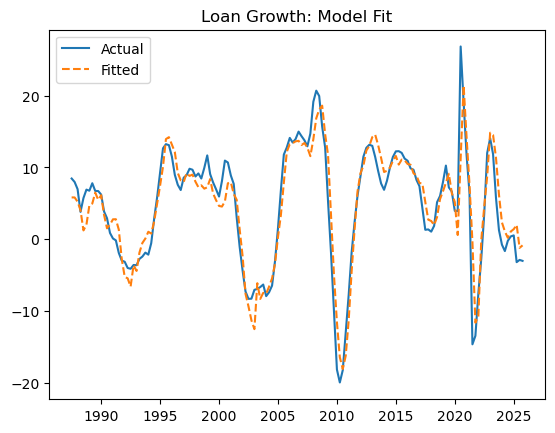

In [12]:
import statsmodels.api as sm

# -------------------------------------------------
# Step 1: Prepare lagged variables
# -------------------------------------------------
df_reg = df_history.copy()

# Lag macro variables by 1 quarter
df_reg['Loan_Growth_Lag1'] = df_reg['Loan_Growth'].shift(1)
df_reg['Chargeoff_Lag1'] = df_reg['Chargeoff_Rate'].shift(1)
df_reg['Inflation_Lag1'] = df_reg['Inflation'].shift(1)
df_reg['Unemployment_Lag1'] = df_reg['Unemployment_Rate'].shift(1)
df_reg['GDP_Lag1'] = df_reg['GDP_Growth'].shift(1)

# Drop missing rows due to lagging
df_reg = df_reg.dropna()

# -------------------------------------------------
# Step 2: Define dependent and independent variables
# -------------------------------------------------

# Loan Growth OLS
y_loan = df_reg['Loan_Growth']
X_loan = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy',
                 'Loan_Growth_Lag1', 'Chargeoff_Lag1']]  # add lags to see predictive power
X_loan = sm.add_constant(X_loan)

# Charge-off Rate OLS
y_charge = df_reg['Chargeoff_Rate']
X_charge = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy',
                   'Loan_Growth_Lag1', 'Chargeoff_Lag1']]  # same set of predictors
X_charge = sm.add_constant(X_charge)

# -------------------------------------------------
# Step 3: Fit the models
# -------------------------------------------------
model_loan = sm.OLS(y_loan, X_loan).fit()
model_charge = sm.OLS(y_charge, X_charge).fit()

# -------------------------------------------------
# Step 4: Review summaries
# -------------------------------------------------
print("------ Loan Growth Regression ------")
print(model_loan.summary())
print("\n------ Charge-Off Rate Regression ------")
print(model_charge.summary())

import matplotlib.pyplot as plt

# Loan Growth
df_reg['Loan_Fitted'] = model_loan.fittedvalues

plt.figure()
plt.plot(df_reg.index, df_reg['Loan_Growth'], label='Actual')
plt.plot(df_reg.index, df_reg['Loan_Fitted'], linestyle='--', label='Fitted')
plt.title('Loan Growth: Model Fit')
plt.legend()
plt.show()


# these are the models without lags

In [13]:
# -----------------------------------------
# Charge-off model WITHOUT persistence
# -----------------------------------------

y_charge = df_reg['Chargeoff_Rate']

X_charge_nolag = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy']]
X_charge_nolag = sm.add_constant(X_charge_nolag)

model_charge_nolag = sm.OLS(y_charge, X_charge_nolag).fit()

print(model_charge_nolag.summary())

# -----------------------------------------
# Loan Growth WITHOUT persistence
# -----------------------------------------

y_loan = df_reg['Loan_Growth']

X_loan_nolag = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy']]
X_loan_nolag = sm.add_constant(X_loan_nolag)

model_loan_nolag = sm.OLS(y_loan, X_loan_nolag).fit()

print(model_loan_nolag.summary())

                            OLS Regression Results                            
Dep. Variable:         Chargeoff_Rate   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     20.16
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.75e-13
Time:                        10:10:54   Log-Likelihood:                -98.322
No. Observations:                 154   AIC:                             206.6
Df Residuals:                     149   BIC:                             221.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0621      0.20

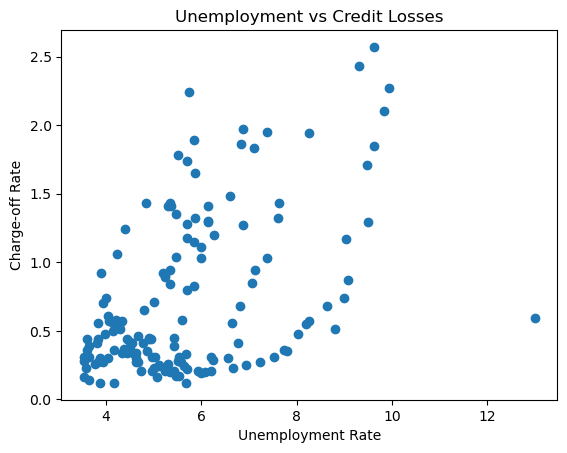

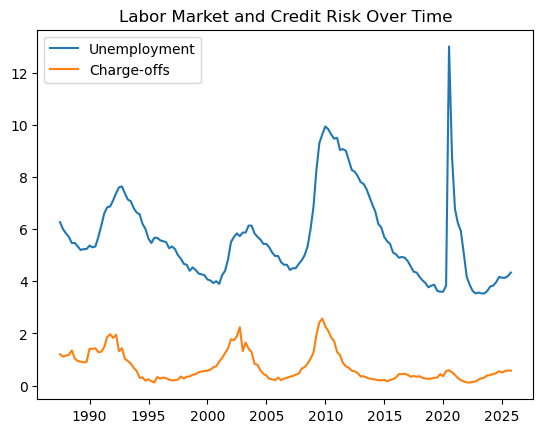

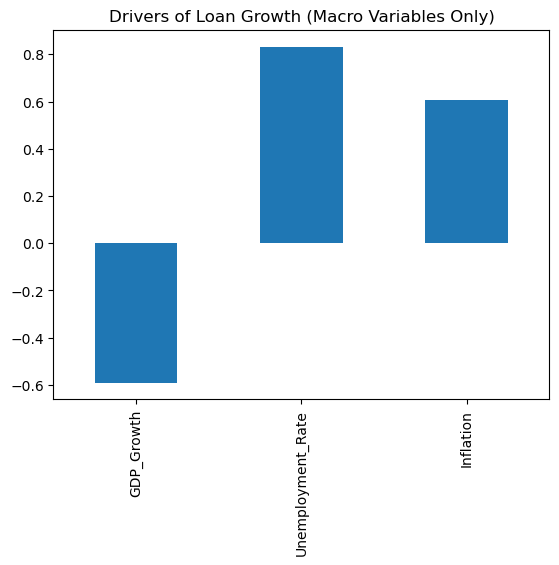

In [14]:
plt.figure()
plt.scatter(df_reg['Unemployment_Rate'], df_reg['Chargeoff_Rate'])
plt.title('Unemployment vs Credit Losses')
plt.xlabel('Unemployment Rate')
plt.ylabel('Charge-off Rate')
plt.show()

plt.figure()
plt.plot(df_reg.index, df_reg['Unemployment_Rate'], label='Unemployment')
plt.plot(df_reg.index, df_reg['Chargeoff_Rate'], label='Charge-offs')
plt.title('Labor Market and Credit Risk Over Time')
plt.legend()
plt.show()

coef = model_loan.params.drop('const')

# keep only macro variables (remove lags + COVID)
coef_filtered = coef[['GDP_Growth', 'Unemployment_Rate', 'Inflation']]

plt.figure()
coef_filtered.plot(kind='bar')
plt.title('Drivers of Loan Growth (Macro Variables Only)')
plt.show()

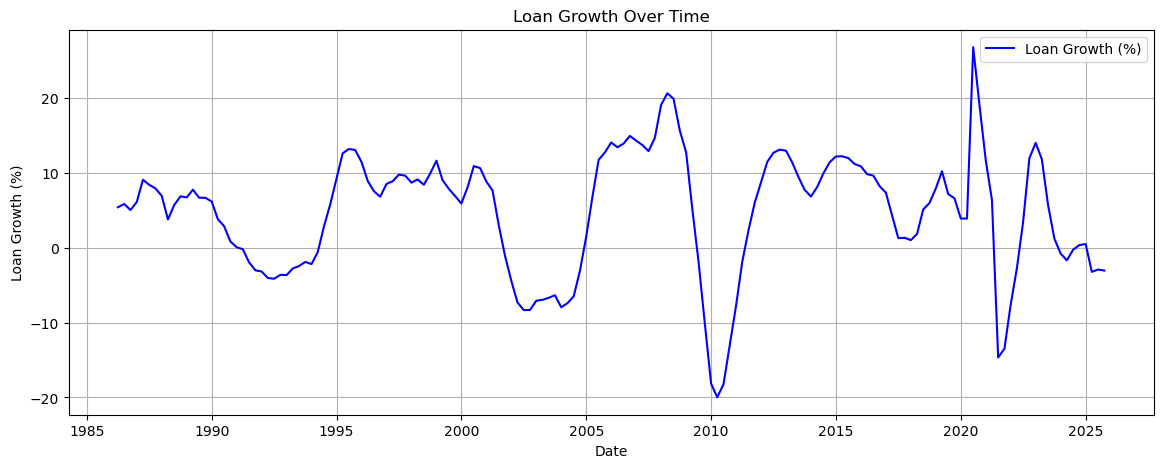

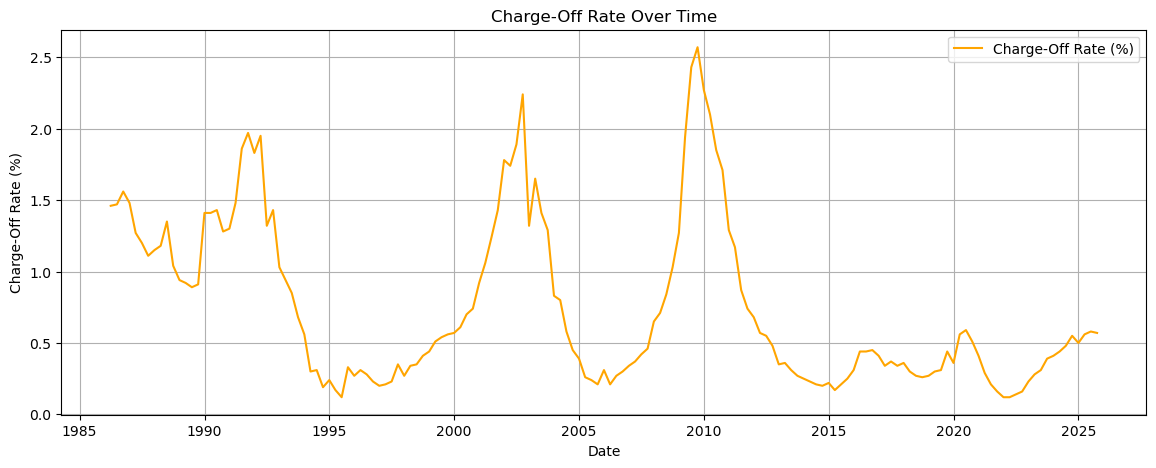

In [15]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = df_history.copy()
df_plot.index = pd.to_datetime(df_plot.index)

# -----------------------------
# Loan Growth Over Time
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(df_plot.index, df_plot['Loan_Growth'], color='blue', label='Loan Growth (%)')
plt.xlabel('Date')
plt.ylabel('Loan Growth (%)')
plt.title('Loan Growth Over Time')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Charge-Off Rate Over Time
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(df_plot.index, df_plot['Chargeoff_Rate'], color='orange', label='Charge-Off Rate (%)')
plt.xlabel('Date')
plt.ylabel('Charge-Off Rate (%)')
plt.title('Charge-Off Rate Over Time')
plt.grid(True)
plt.legend()
plt.show()

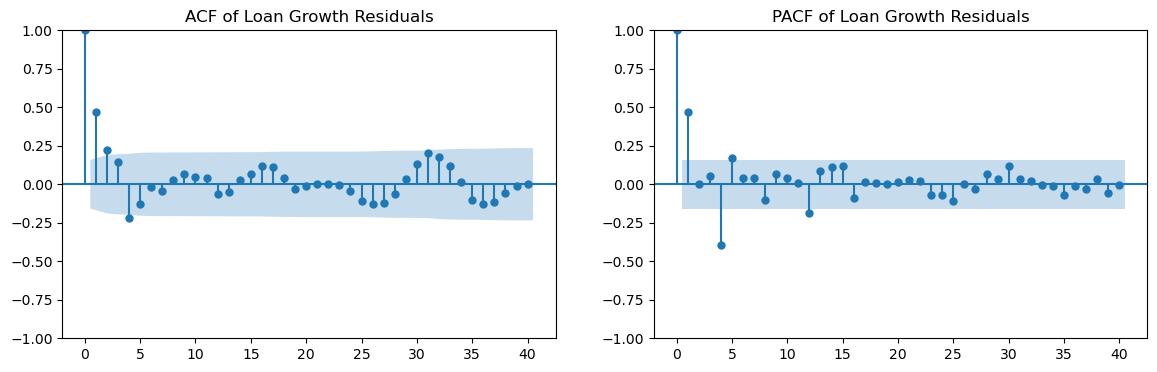

In [16]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example for Loan Growth residuals
resid_loan = model_loan.resid  # residuals from your OLS

# Plot ACF
fig, ax = plt.subplots(1,2, figsize=(14,4))
sm.graphics.tsa.plot_acf(resid_loan, lags=40, ax=ax[0])
ax[0].set_title('ACF of Loan Growth Residuals')

# Plot PACF
sm.graphics.tsa.plot_pacf(resid_loan, lags=40, ax=ax[1])
ax[1].set_title('PACF of Loan Growth Residuals')

plt.show()

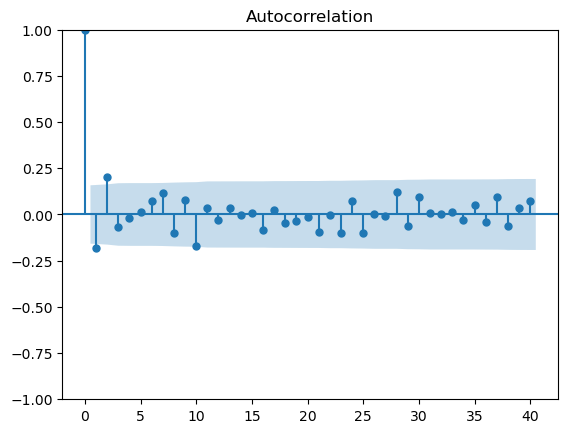

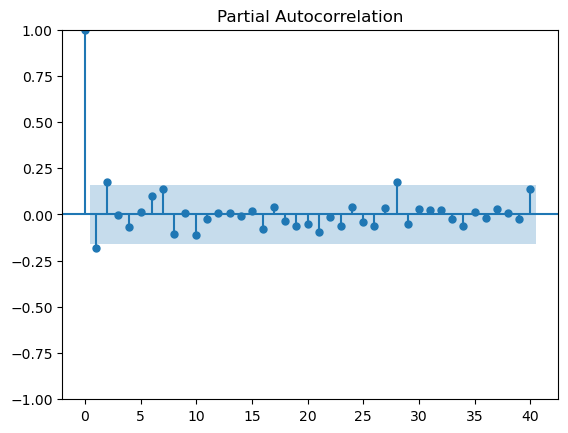

In [17]:
resid_charge = model_charge.resid
sm.graphics.tsa.plot_acf(resid_charge, lags=40)
sm.graphics.tsa.plot_pacf(resid_charge, lags=40)
plt.show()

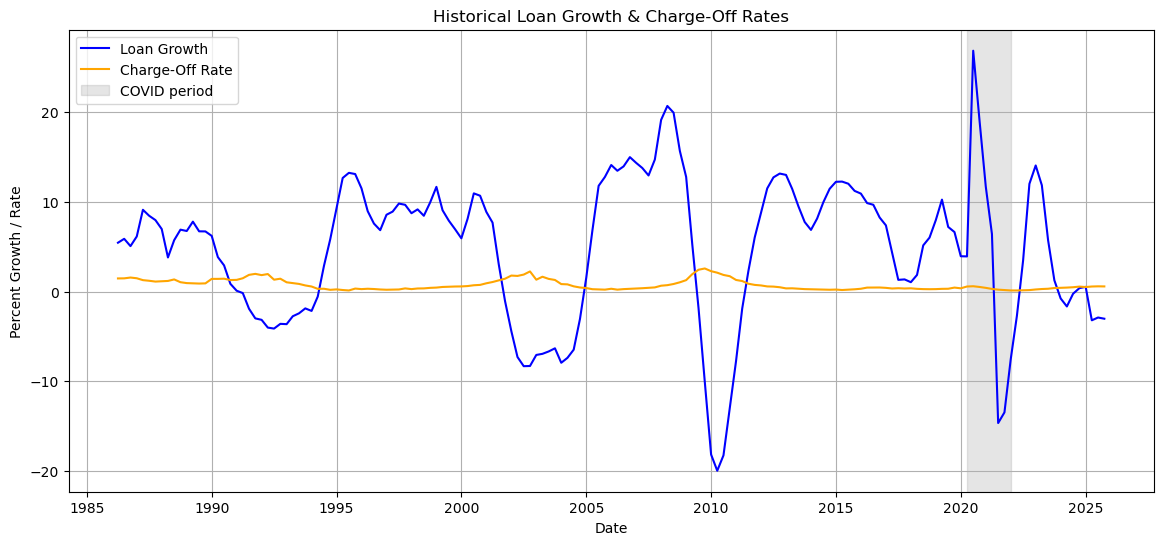

In [18]:
import matplotlib.pyplot as plt

# Historical data
plt.figure(figsize=(14,6))
plt.plot(df_history.index, df_history['Loan_Growth'], label='Loan Growth', color='blue')
plt.plot(df_history.index, df_history['Chargeoff_Rate'], label='Charge-Off Rate', color='orange')

# Highlight COVID period
plt.axvspan(pd.to_datetime('2020-03-31'), pd.to_datetime('2021-12-31'), color='gray', alpha=0.2, label='COVID period')

plt.title("Historical Loan Growth & Charge-Off Rates")
plt.xlabel("Date")
plt.ylabel("Percent Growth / Rate")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd

# Load NGFS Excel sheet
ngfs_file = "Downscaled_GCAM 6.0 NGFS_data.xlsx"
sheet_name = "data"  # adjust if your sheet is named differently

# Read the sheet
ngfs_df = pd.read_excel(ngfs_file, sheet_name=sheet_name)

# Show the first few rows
print(ngfs_df.head())

# List all columns
print("\nColumns in NGFS sheet:")
print(ngfs_df.columns.tolist())

                        Model            Scenario Region  \
0  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
1  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
2  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
3  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
4  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   

                                        Variable       Unit      2020  2021  \
0                       Carbon Sequestration|CCS  Mt CO2/yr    0.0000   NaN   
1               Carbon Sequestration|CCS|Biomass  Mt CO2/yr    0.0000   NaN   
2                Carbon Sequestration|CCS|Fossil  Mt CO2/yr    0.0000   NaN   
3  Carbon Sequestration|CCS|Industrial Processes  Mt CO2/yr    0.0000   NaN   
4                                  Emissions|CO2  Mt CO2/yr  148.1421   NaN   

   2022  2023  2024  ...  2091  2092  2093  2094  2095  2096  2097  2098  \
0   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   Na

In [20]:
import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Clean FRED / historical data
# -----------------------------
def clean_fred_data(file_path, value_col_name):
    df = pd.read_csv(file_path)
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    df_q = df_numeric.resample('QE').mean()  # quarterly
    df_q.columns = [value_col_name]
    return df_q

# Load historical data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')  # your GDP CSV

# Combine into one master historical DataFrame
df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge, df_gdp], axis=1).dropna()

# -----------------------------
# 2️⃣ Feature engineering
# -----------------------------
# Quarterly growth / differences
df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
df_history['GDP_Growth'] = df_history['GDP'].pct_change(4) * 100

# Lagged variables for regression / ARIMAX later
df_history['Loan_Growth_Lag1'] = df_history['Loan_Growth'].shift(1)
df_history['Chargeoff_Lag1'] = df_history['Chargeoff_Rate'].shift(1)

# -----------------------------
# 3️⃣ Create COVID dummy
# -----------------------------
covid_start = '2020-03-31'
covid_end = '2021-12-31'
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Drop NA rows after creating growth rates and lags
df_history = df_history.dropna()

# -----------------------------
# ✅ Quick check
# -----------------------------
print(df_history.head())
print("\nColumns:", df_history.columns.tolist())

                  Loans_Billions         CPI  Unemployment_Rate  \
observation_date                                                  
1986-06-30            508.855633  109.033333           7.166667   
1986-09-30            515.118767  109.700000           6.966667   
1986-12-31            526.926900  110.466667           6.833333   
1987-03-31            548.151267  111.800000           6.600000   
1987-06-30            551.837367  113.066667           6.266667   

                  Chargeoff_Rate       GDP  Loan_Growth  Inflation  \
observation_date                                                     
1986-06-30                  1.47  8788.524     5.876495   1.678583   
1986-09-30                  1.56  8872.601     5.060920   1.668211   
1986-12-31                  1.48  8920.193     6.140820   1.345566   
1987-03-31                  1.27  8986.367     9.112131   2.038333   
1987-06-30                  1.20  9083.256     8.446744   3.699175   

                  GDP_Growth  Loan_Grow

In [21]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [22]:
print(ngfs_quarterly.columns)

Index(['Below 2°C_Carbon pricing ; $ per Tn CO2(combined)',
       'Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Below 2°C_Coal price ; US$ per barrel (equiv)(combined)',
       'Below 2°C_Consumption (private)(combined)',
       'Below 2°C_Domestic demand(combined)',
       'Below 2°C_Effective exchange rate(combined)',
       'Below 2°C_Energy consumption (total) ; MnToe(combined)',
       'Below 2°C_Equity prices(combined)',
       'Below 2°C_Exports (goods and services)(combined)',
       'Below 2°C_Gas price ; US$ per barrel (equiv)(combined)',
       ...
       'Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined)',
       'Net Zero 2050_Quarterly consumption of coal ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of gas ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of oil ; MnToe(combined)',
       'Net Zero 2

Loading Data...
Smoothing 2020 Volatility...
✅ Data Prepared & Smoothed. Training Rows: 309

Training ARIMA(2,0,1)x(1,0,0,4)...
                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  309
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -706.827
Date:                Thu, 09 Apr 2026   AIC                           1425.654
Time:                        10:11:41   BIC                           1448.054
Sample:                    03-31-1949   HQIC                          1434.610
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                13.5699      2.625      5.170      0.000       

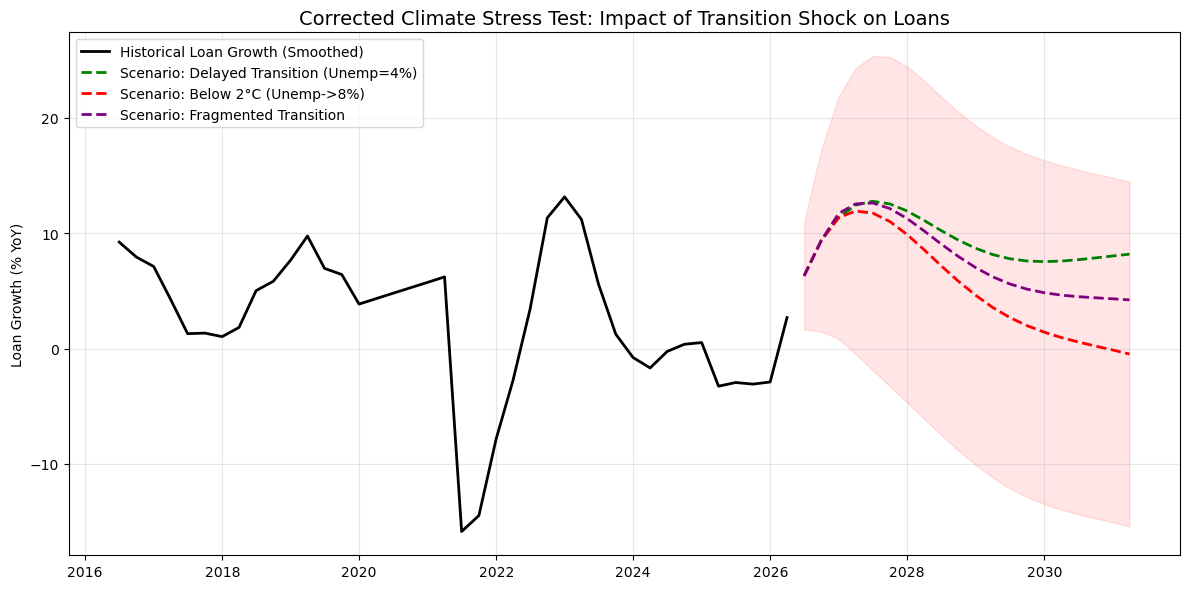

✅ Analysis Complete.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. ROBUST DATA CLEANING (Standardized)
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        # Find date column
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        
        # Force numeric and resample to Quarter End
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        print(f"⚠️ Error cleaning {file_path}: {e}")
        return pd.DataFrame()

# ---------------------------------------------------------
# 2. LOAD & PREPARE DATA
# ---------------------------------------------------------
print("Loading Data...")
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

# Merge
df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()

# Create Initial Target: Loan Growth (Log Difference)
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# ---------------------------------------------------------
# 3. WINSORIZE (SMOOTH) THE 2020 SHOCK
# ---------------------------------------------------------
# We smooth BOTH the Target (Loans) and the Input (Unemployment)
# to prevent the model from learning "broken" economics from the pandemic.
print("Smoothing 2020 Volatility...")

shock_start = '2020-01-01'
shock_end = '2020-12-31'

# A. Smooth Loans
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear')

# B. Smooth Unemployment (CRITICAL fix for logic)
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (Post-Smoothing)
# ---------------------------------------------------------
# We calculate lags *after* smoothing so the shock doesn't "leak" into the lag
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)

# Drop NaNs created by shifting/differencing
df_train = df_history.dropna()

print(f"✅ Data Prepared & Smoothed. Training Rows: {len(df_train)}")

# ---------------------------------------------------------
# 5. TRAIN MODEL (Optimized SARIMA)
# ---------------------------------------------------------
# Y = Loan Growth
# X = Unemployment (Lagged)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag2']] 

print("\nTraining ARIMA(2,0,1)x(1,0,0,4)...")
model = ARIMA(y, exog=X, order=(2, 0, 1)) 
model_fit = model.fit()

print(model_fit.summary())

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS
# ---------------------------------------------------------
steps = 20 # 5 Years
future_dates = pd.date_range(start=df_train.index[-1], periods=steps+1, freq='QE')[1:]

# --- Scenario A: Delayed Transition (Low Stress) ---
# Unemployment stays flat/low (4.0%)
future_delayed = pd.DataFrame(index=future_dates)
future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                    df_history['Unemployment_Rate'].iloc[-1], 
                                                    steps)
future_delayed['Loans_Billions'] = 0 # Placeholder
future_delayed['CPI'] = 0 # Placeholder

# Combine with history to calculate lags correctly
df_total_delayed = pd.concat([df_history, future_delayed])
df_total_delayed['Unemployment_Lag2'] = df_total_delayed['Unemployment_Rate'].shift(2)
# Slice back to just the future part
X_future_delayed = df_total_delayed.iloc[-steps:][['Unemployment_Lag2']]


# --- Scenario B: Below 2°C (High Stress) ---
# Unemployment spikes to 8% due to transition shock
future_stress = pd.DataFrame(index=future_dates)
future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                    df_history['Unemployment_Rate'].iloc[-1]+8, 
                                                    steps)
future_stress['Loans_Billions'] = 0
future_stress['CPI'] = 0

# Combine & Lag
df_total_stress = pd.concat([df_history, future_stress])
df_total_stress['Unemployment_Lag2'] = df_total_stress['Unemployment_Rate'].shift(2)
# Slice
X_future_stress = df_total_stress.iloc[-steps:][['Unemployment_Lag2']]

# Scenario C: fragmented 
future_fragmented = pd.DataFrame(index=future_dates)
future_fragmented['Unemployment_Rate'] = np.linspace(4.0, 8.0, steps)
future_fragmented['Physical_Risk_Dummy'] = 0
future_fragmented.loc[future_fragmented.index >= future_fragmented.index[12], 'Physical_Risk_Dummy'] = 1
future_fragmented['Loans_Billions'] = 0
future_fragmented['CPI'] = 0
# Combine & Lag
df_total_fragmented = pd.concat([df_history, future_fragmented])
df_total_fragmented['Unemployment_Lag2'] = df_total_fragmented['Unemployment_Rate'].shift(2)
# slice 
X_future_fragmented = df_total_fragmented.iloc[-steps:]['Unemployment_Lag2']

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
print("\nRunning Forecasts...")

# Forecast A (Delayed)
forecast_delayed = model_fit.get_forecast(steps=steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

# Forecast B (Stress)
forecast_stress = model_fit.get_forecast(steps=steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int = forecast_stress.conf_int(alpha=0.05) # 95% Confidence Interval
# Forecast C (fragmented)
forecast_fragmented = model_fit.get_forecast(steps=steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot History (Last 10 Years)
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# Plot Delayed (Green)
plt.plot(pred_delayed.index, pred_delayed, 
         label='Scenario: Delayed Transition (Unemp=4%)', color='green', linestyle='--', linewidth=2)

# Plot Stress (Red)
plt.plot(pred_stress.index, pred_stress, 
         label='Scenario: Below 2°C (Unemp->8%)', color='red', linestyle='--', linewidth=2)
# Plot Fragmented (Purple)
plt.plot(pred_fragmented.index, pred_fragmented, 
         label='Scenario: Fragmented Transition', color='purple', linestyle='--', linewidth=2)
# Confidence Interval (Red Shading)
plt.fill_between(pred_stress.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1)

plt.title('Corrected Climate Stress Test: Impact of Transition Shock on Loans', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Analysis Complete.")

In [24]:
import sys
print(sys.executable)

/Users/geoffpoint-du-jour/opt/anaconda3/envs/econ524/bin/python


Loading Historical Data...
✅ Data Prepared. Training Rows: 161
                  Chargeoff_Rate  Unemployment_Rate  Chargeoff_Lag1  \
observation_date                                                      
1985-09-30                  1.42           7.200000            1.20   
1985-12-31                  1.45           7.033333            1.42   
1986-03-31                  1.46           7.033333            1.45   
1986-06-30                  1.47           7.166667            1.46   
1986-09-30                  1.56           6.966667            1.47   

                  Unemployment_Lag1  
observation_date                     
1985-09-30                 7.300000  
1985-12-31                 7.200000  
1986-03-31                 7.033333  
1986-06-30                 7.033333  
1986-09-30                 7.166667  

Training ARIMAX Model for Charge-Off Rate...
                               SARIMAX Results                                
Dep. Variable:         Chargeoff_Rate   No. Obse

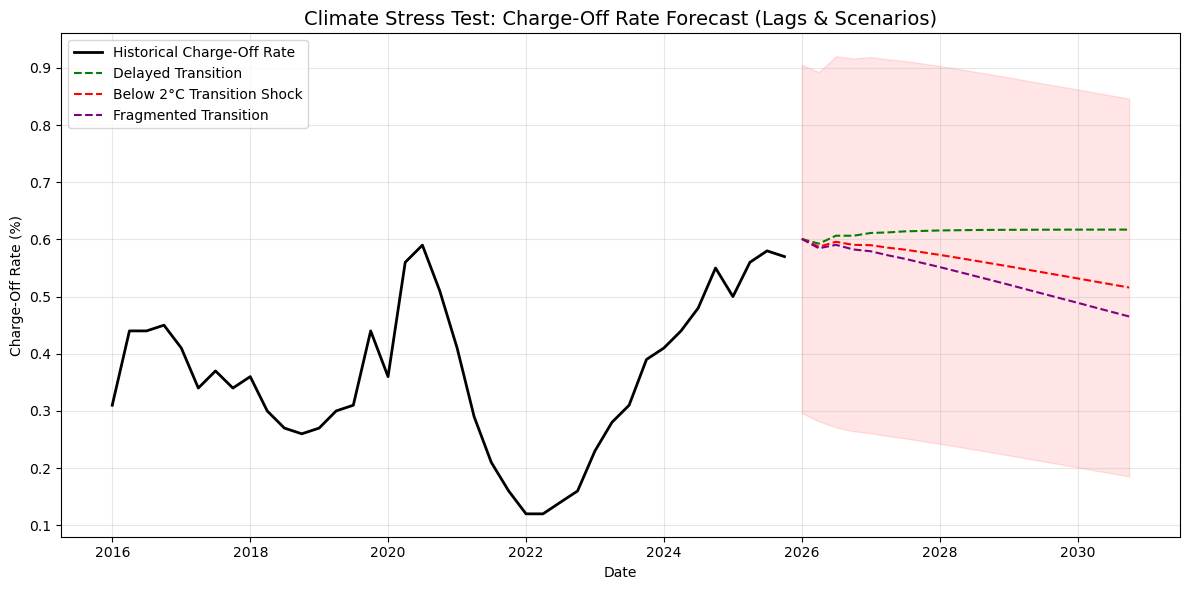

✅ Charge-Off Rate Stress Test Complete.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. ROBUST DATA CLEANING
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        # Find date column dynamically
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        # Force numeric and resample quarterly
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        print(f"⚠️ Error cleaning {file_path}: {e}")
        return pd.DataFrame()

# ---------------------------------------------------------
# 2. LOAD HISTORICAL DATA
# ---------------------------------------------------------
print("Loading Historical Data...")
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')

# Combine into master DataFrame
df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge], axis=1).dropna()

# ---------------------------------------------------------
# 3. FEATURE ENGINEERING
# ---------------------------------------------------------
# Calculate lagged variables and growth rates
df_history['Chargeoff_Lag1'] = df_history['Chargeoff_Rate'].shift(1)
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)

# COVID Dummy
covid_start, covid_end = '2020-03-31', '2021-12-31'
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Drop rows with NA from lagging
df_train = df_history.dropna()

print(f"✅ Data Prepared. Training Rows: {len(df_train)}")
print(df_train[['Chargeoff_Rate','Unemployment_Rate','Chargeoff_Lag1','Unemployment_Lag1']].head())

# ---------------------------------------------------------
# 4. FIT ARIMAX MODEL
# ---------------------------------------------------------
y = df_train['Chargeoff_Rate']
X = df_train[['Chargeoff_Lag1','Unemployment_Lag1','Unemployment_Lag2','COVID_Dummy']]

print("\nTraining ARIMAX Model for Charge-Off Rate...")
model = ARIMA(y, exog=X, order=(2,0,1))
model_fit = model.fit()
print(model_fit.summary())

# ---------------------------------------------------------
# 5. GENERATE SCENARIO PROXIES
# ---------------------------------------------------------
steps = 20  # 5 years
future_dates = pd.date_range(start=df_train.index[-1], periods=steps+1, freq='QE')[1:]

last_chargeoff = df_train['Chargeoff_Rate'].iloc[-1]
last_unemp = df_train['Unemployment_Rate'].iloc[-1]

# --- Scenario A: Delayed Transition (Low Stress) ---
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Chargeoff_Lag1'] = last_chargeoff
X_future_delayed['Unemployment_Lag1'] = last_unemp
X_future_delayed['Unemployment_Lag2'] = last_unemp  # flat
X_future_delayed['COVID_Dummy'] = 0

# --- Scenario B: Below 2°C Transition Shock (High Stress) ---
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Chargeoff_Lag1'] = last_chargeoff
X_future_stress['Unemployment_Lag1'] = last_unemp
X_future_stress['Unemployment_Lag2'] = last_unemp + np.linspace(0, 4.0, steps)  # spike
X_future_stress['COVID_Dummy'] = 0

# --- Scenario C: Fragmented Transition ---
X_future_fragmented = pd.DataFrame(index=future_dates)
X_future_fragmented['Chargeoff_Lag1'] = last_chargeoff
X_future_fragmented['Unemployment_Lag1'] = last_unemp
X_future_fragmented['Unemployment_Lag2'] = last_unemp + np.linspace(0, 6.0, steps)
X_future_fragmented['COVID_Dummy'] = 0

# ---------------------------------------------------------
# 6. RUN FORECASTS
# ---------------------------------------------------------
forecast_delayed = model_fit.get_forecast(steps=steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean

# ---------------------------------------------------------
# 7. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Historical Charge-Off Rate
plt.plot(df_train.index[-40:], df_train['Chargeoff_Rate'][-40:], label='Historical Charge-Off Rate', color='black', linewidth=2)

# Scenario Delayed
plt.plot(pred_delayed.index, pred_delayed, label='Delayed Transition', color='green', linestyle='--')

# Scenario Stress
plt.plot(pred_stress.index, pred_stress, label='Below 2°C Transition Shock', color='red', linestyle='--')

# Scenario Fragmented
plt.plot(pred_fragmented.index, pred_fragmented, label='Fragmented Transition', color='purple', linestyle='--')

# Confidence Interval for Stress
plt.fill_between(pred_stress.index, conf_int_stress.iloc[:,0], conf_int_stress.iloc[:,1], color='red', alpha=0.1)

plt.title('Climate Stress Test: Charge-Off Rate Forecast (Lags & Scenarios)', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("✅ Charge-Off Rate Stress Test Complete.")

Loading Historical Data...
Training rows: 161
Training AR Model...
                               SARIMAX Results                                
Dep. Variable:         Chargeoff_Rate   No. Observations:                  161
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  70.909
Date:                Thu, 09 Apr 2026   AIC                           -123.818
Time:                        10:11:42   BIC                            -96.085
Sample:                    09-30-1985   HQIC                          -112.557
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2089      0.196      1.064      0.287      -0.176       0.594
Chargeoff_Lag1        0.7896      0.320    

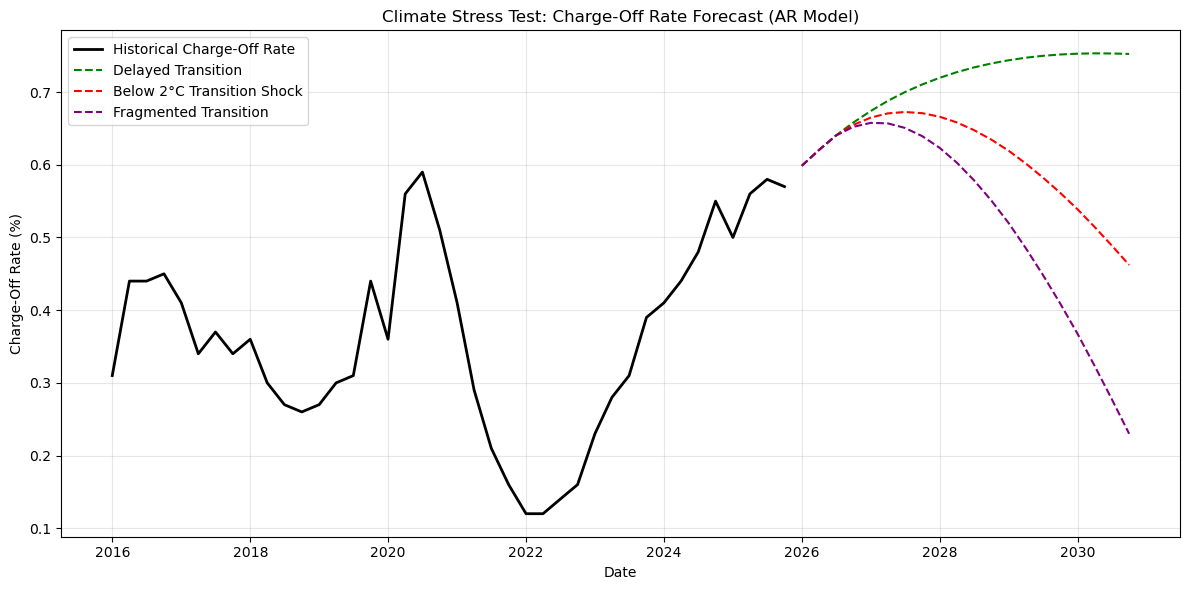

Charge-Off Rate Stress Test Complete.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. ROBUST DATA CLEANING
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):

    df = pd.read_csv(file_path)

    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])

    df = df.set_index(date_col)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.select_dtypes(include=[np.number])

    df_q = df.resample('QE').mean()

    if not df_q.empty:
        df_q.columns = [value_col_name]

    return df_q


# ---------------------------------------------------------
# 2. LOAD HISTORICAL DATA
# ---------------------------------------------------------
print("Loading Historical Data...")

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')

df_history = pd.concat(
    [df_loans, df_cpi, df_unemp, df_charge],
    axis=1
).dropna()

# ---------------------------------------------------------
# 3. FEATURE ENGINEERING
# ---------------------------------------------------------
df_history['Chargeoff_Lag1'] = df_history['Chargeoff_Rate'].shift(1)
df_history['Chargeoff_Lag2'] = df_history['Chargeoff_Rate'].shift(2)

df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)

# COVID dummy
covid_start = '2020-03-31'
covid_end = '2021-12-31'

df_history['COVID_Dummy'] = 0
df_history.loc[
    (df_history.index >= covid_start) &
    (df_history.index <= covid_end),
    'COVID_Dummy'
] = 1

df_train = df_history.dropna()

print("Training rows:", len(df_train))


# ---------------------------------------------------------
# 4. FIT AR MODEL (ARX)
# ---------------------------------------------------------
y = df_train['Chargeoff_Rate']

X = df_train[
    [
        'Chargeoff_Lag1',
        'Chargeoff_Lag2',
        'Unemployment_Lag1',
        'Unemployment_Lag2',
        'COVID_Dummy'
    ]
]

print("Training AR Model...")

model = ARIMA(y, exog=X, order=(2,0,0))
model_fit = model.fit()

print(model_fit.summary())


# ---------------------------------------------------------
# 5. BUILD SCENARIO PATHS
# ---------------------------------------------------------
steps = 20

future_dates = pd.date_range(
    start=df_train.index[-1],
    periods=steps+1,
    freq='QE'
)[1:]

last_charge1 = df_train['Chargeoff_Rate'].iloc[-1]
last_charge2 = df_train['Chargeoff_Rate'].iloc[-2]

last_unemp = df_train['Unemployment_Rate'].iloc[-1]


# Scenario A: Delayed Transition
unemp_delayed = last_unemp + np.linspace(0,0.5,steps)

# Scenario B: Below 2C Shock
unemp_stress = last_unemp + np.linspace(0,3,steps)

# Scenario C: Fragmented
unemp_fragmented = last_unemp + np.linspace(0,5,steps)


# ---------------------------------------------------------
# 6. FORECAST FUNCTION (dynamic lags)
# ---------------------------------------------------------
def run_forecast(unemp_path):

    charge_lag1 = last_charge1
    charge_lag2 = last_charge2

    preds = []

    for i in range(steps):

        if i == 0:
            unemp_lag1 = last_unemp
            unemp_lag2 = last_unemp
        elif i == 1:
            unemp_lag1 = unemp_path[i-1]
            unemp_lag2 = last_unemp
        else:
            unemp_lag1 = unemp_path[i-1]
            unemp_lag2 = unemp_path[i-2]

        X_future = pd.DataFrame({

            'Chargeoff_Lag1':[charge_lag1],
            'Chargeoff_Lag2':[charge_lag2],
            'Unemployment_Lag1':[unemp_lag1],
            'Unemployment_Lag2':[unemp_lag2],
            'COVID_Dummy':[0]

        })

        pred = model_fit.forecast(exog=X_future)[0]

        preds.append(pred)

        charge_lag2 = charge_lag1
        charge_lag1 = pred

    return pd.Series(preds, index=future_dates)


pred_delayed = run_forecast(unemp_delayed)
pred_stress = run_forecast(unemp_stress)
pred_fragmented = run_forecast(unemp_fragmented)


# ---------------------------------------------------------
# 7. PLOT RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    df_train.index[-40:],
    df_train['Chargeoff_Rate'][-40:],
    color='black',
    linewidth=2,
    label='Historical Charge-Off Rate'
)

plt.plot(
    pred_delayed,
    linestyle='--',
    color='green',
    label='Delayed Transition'
)

plt.plot(
    pred_stress,
    linestyle='--',
    color='red',
    label='Below 2°C Transition Shock'
)

plt.plot(
    pred_fragmented,
    linestyle='--',
    color='purple',
    label='Fragmented Transition'
)

plt.title('Climate Stress Test: Charge-Off Rate Forecast (AR Model)')
plt.ylabel('Charge-Off Rate (%)')
plt.xlabel('Date')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Charge-Off Rate Stress Test Complete.")

Loading Data...
Training rows: 307
Training AR Model...
                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  307
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -701.876
Date:                Thu, 09 Apr 2026   AIC                           1417.751
Time:                        10:11:42   BIC                           1443.839
Sample:                    09-30-1949   HQIC                          1428.184
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.6599      0.500      1.319      0.187      -0.321       1.641
Loan_Lag1             1.6345      0.059     27.847    

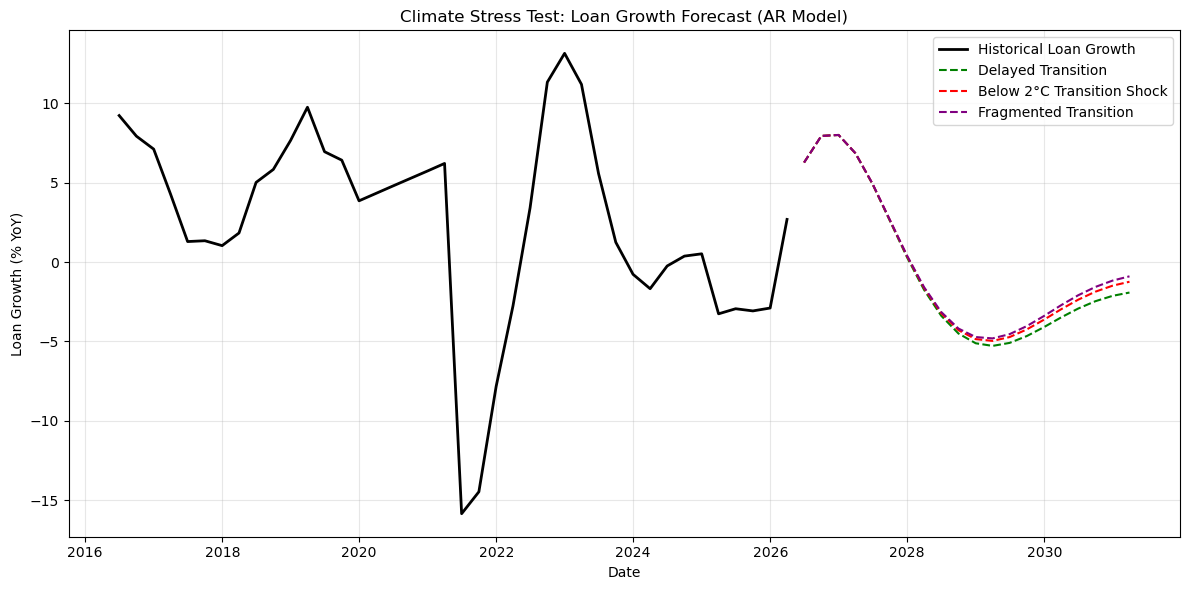

✅ Loan Growth Stress Test Complete.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. DATA CLEANING
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):

    df = pd.read_csv(file_path)

    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.select_dtypes(include=[np.number])

    df_q = df.resample('QE').mean()

    if not df_q.empty:
        df_q.columns = [value_col_name]

    return df_q


# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
print("Loading Data...")

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_loans, df_unemp], axis=1).dropna()


# ---------------------------------------------------------
# 3. CREATE LOAN GROWTH
# ---------------------------------------------------------
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100


# ---------------------------------------------------------
# 4. SMOOTH PANDEMIC
# ---------------------------------------------------------
shock_start = '2020-01-01'
shock_end = '2020-12-31'

df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate()

df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate()


# ---------------------------------------------------------
# 5. FEATURE ENGINEERING
# ---------------------------------------------------------
df_history['Loan_Lag1'] = df_history['Loan_Growth'].shift(1)
df_history['Loan_Lag2'] = df_history['Loan_Growth'].shift(2)

df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)

df_train = df_history.dropna()

print("Training rows:", len(df_train))


# ---------------------------------------------------------
# 6. TRAIN AR MODEL
# ---------------------------------------------------------
y = df_train['Loan_Growth']

X = df_train[
    [
        'Loan_Lag1',
        'Loan_Lag2',
        'Unemployment_Lag2'
    ]
]

print("Training AR Model...")

model = ARIMA(y, exog=X, order=(2,0,0))
model_fit = model.fit()

print(model_fit.summary())


# ---------------------------------------------------------
# 7. CREATE SCENARIOS
# ---------------------------------------------------------
steps = 20

future_dates = pd.date_range(
    start=df_train.index[-1],
    periods=steps+1,
    freq='QE'
)[1:]

last_growth1 = df_train['Loan_Growth'].iloc[-1]
last_growth2 = df_train['Loan_Growth'].iloc[-2]

last_unemp = df_train['Unemployment_Rate'].iloc[-1]


# Scenario A: Delayed Transition
unemp_delayed = np.linspace(last_unemp, last_unemp, steps)

# Scenario B: Below 2°C Shock
unemp_stress = np.linspace(last_unemp, last_unemp + 4, steps)

# Scenario C: Fragmented
unemp_fragmented = np.linspace(last_unemp, last_unemp + 6, steps)


# ---------------------------------------------------------
# 8. DYNAMIC FORECAST FUNCTION
# ---------------------------------------------------------
def run_forecast(unemp_path):

    loan_lag1 = last_growth1
    loan_lag2 = last_growth2

    preds = []

    for i in range(steps):

        if i == 0:
            unemp_lag2 = last_unemp
        elif i == 1:
            unemp_lag2 = last_unemp
        else:
            unemp_lag2 = unemp_path[i-2]

        X_future = pd.DataFrame({

            'Loan_Lag1':[loan_lag1],
            'Loan_Lag2':[loan_lag2],
            'Unemployment_Lag2':[unemp_lag2]

        })

        pred = model_fit.forecast(exog=X_future)[0]

        preds.append(pred)

        loan_lag2 = loan_lag1
        loan_lag1 = pred

    return pd.Series(preds, index=future_dates)


pred_delayed = run_forecast(unemp_delayed)
pred_stress = run_forecast(unemp_stress)
pred_fragmented = run_forecast(unemp_fragmented)


# ---------------------------------------------------------
# 9. PLOT RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    df_train.index[-40:],
    df_train['Loan_Growth'][-40:],
    color='black',
    linewidth=2,
    label='Historical Loan Growth'
)

plt.plot(
    pred_delayed,
    linestyle='--',
    color='green',
    label='Delayed Transition'
)

plt.plot(
    pred_stress,
    linestyle='--',
    color='red',
    label='Below 2°C Transition Shock'
)

plt.plot(
    pred_fragmented,
    linestyle='--',
    color='purple',
    label='Fragmented Transition'
)

plt.title('Climate Stress Test: Loan Growth Forecast (AR Model)')
plt.ylabel('Loan Growth (% YoY)')
plt.xlabel('Date')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Loan Growth Stress Test Complete.")

In [28]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# CLEAN DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):

    df = pd.read_csv(file_path)

    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.select_dtypes(include=[np.number])

    df_q = df.resample('QE').mean()

    if not df_q.empty:
        df_q.columns = [value_col_name]

    return df_q


# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df_loans = clean_fred_data('BUSLOANS.csv','Loans')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv','Unemployment')
df_charge = clean_fred_data('CORBLACBS.csv','Chargeoff')

df = pd.concat([df_loans,df_unemp,df_charge],axis=1).dropna()


# ---------------------------------------------------------
# CREATE TARGETS
# ---------------------------------------------------------
df['Loan_Growth'] = np.log(df['Loans']).diff(4)*100

df['Unemployment_Lag2'] = df['Unemployment'].shift(2)

df = df.dropna()


loan_y = df['Loan_Growth']
charge_y = df['Chargeoff']

exog = df[['Unemployment_Lag2']]


# ---------------------------------------------------------
# MODEL TEST FUNCTION
# ---------------------------------------------------------
def test_models(y,exog=None):

    results = []

    models = {

        "AR(1)": (1,0,0),
        "AR(2)": (2,0,0),

        "MA(1)": (0,0,1),
        "MA(2)": (0,0,2),

        "ARMA(1,1)": (1,0,1),
        "ARMA(2,1)": (2,0,1),

        "ARIMA(1,1,1)": (1,1,1),
        "ARIMA(2,1,1)": (2,1,1)

    }

    for name,order in models.items():

        try:

            if exog is None:
                model = ARIMA(y,order=order).fit()
            else:
                model = ARIMA(y,exog=exog,order=order).fit()

            results.append({
                "Model":name,
                "AIC":model.aic,
                "BIC":model.bic
            })

        except:
            continue


    df_results = pd.DataFrame(results).sort_values("AIC")

    return df_results


# ---------------------------------------------------------
# RUN TESTS
# ---------------------------------------------------------

print("\n---------------------------")
print("Loan Growth Models")
print("---------------------------")

loan_models = test_models(loan_y)
loan_models_exog = test_models(loan_y,exog)

print("\nWithout Macros")
print(loan_models)

print("\nWith Macros (ARX / ARIMAX)")
print(loan_models_exog)



print("\n---------------------------")
print("Charge-Off Models")
print("---------------------------")

charge_models = test_models(charge_y)
charge_models_exog = test_models(charge_y,exog)

print("\nWithout Macros")
print(charge_models)

print("\nWith Macros (ARX / ARIMAX)")
print(charge_models_exog)


# ---------------------------------------------------------
# BEST MODELS
# ---------------------------------------------------------

print("\nBest Loan Model (No Macros):")
print(loan_models.iloc[0])

print("\nBest Loan Model (With Macros):")
print(loan_models_exog.iloc[0])


print("\nBest Charge-Off Model (No Macros):")
print(charge_models.iloc[0])

print("\nBest Charge-Off Model (With Macros):")
print(charge_models_exog.iloc[0])


---------------------------
Loan Growth Models
---------------------------

Without Macros
          Model         AIC         BIC
5     ARMA(2,1)  819.422965  834.767486
1         AR(2)  821.385009  833.660626
4     ARMA(1,1)  829.122373  841.397990
6  ARIMA(1,1,1)  833.758012  842.945797
7  ARIMA(2,1,1)  835.746875  847.997255
0         AR(1)  857.623264  866.829977
3         MA(2)  889.552757  901.828374
2         MA(1)  931.267496  940.474209

With Macros (ARX / ARIMAX)
          Model         AIC         BIC
5     ARMA(2,1)  820.757176  839.170601
1         AR(2)  822.417210  837.761731
4     ARMA(1,1)  830.150711  845.495232
6  ARIMA(1,1,1)  834.883814  847.134194
7  ARIMA(2,1,1)  836.894628  852.207603
0         AR(1)  856.861274  869.136891
3         MA(2)  891.474207  906.818728
2         MA(1)  932.641529  944.917146

---------------------------
Charge-Off Models
---------------------------

Without Macros
          Model         AIC         BIC
7  ARIMA(2,1,1) -117.355909 -

Loading Data...
Training observations: 157

Loan Model
                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  157
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -371.108
Date:                Thu, 09 Apr 2026   AIC                            756.217
Time:                        10:11:44   BIC                            777.610
Sample:                    09-30-1986   HQIC                           764.905
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5595      1.240      0.451      0.652      -1.870       2.989
Loan_Lag1             1.5879      0.151     10.489     

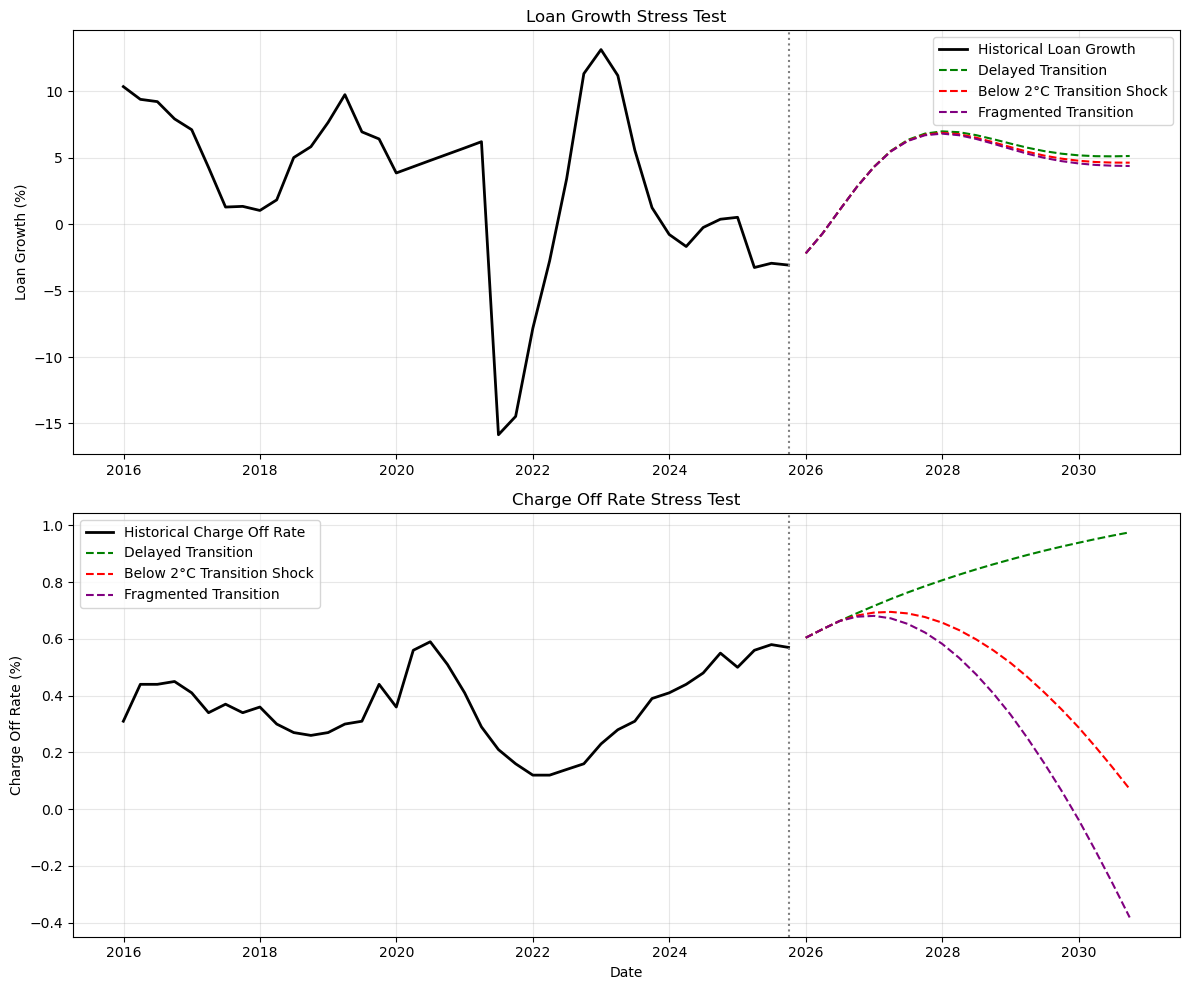

Stress Test Complete.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. DATA CLEANING FUNCTION
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):

    df = pd.read_csv(file_path)

    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])

    df = df.set_index(date_col)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.select_dtypes(include=[np.number])

    df_q = df.resample('QE').mean()

    if not df_q.empty:
        df_q.columns = [value_col_name]

    return df_q


# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
print("Loading Data...")

df_loans = clean_fred_data('BUSLOANS.csv','Loans')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv','Unemployment')
df_charge = clean_fred_data('CORBLACBS.csv','Chargeoff')

df = pd.concat([df_loans,df_unemp,df_charge],axis=1).dropna()


# ---------------------------------------------------------
# 3. CREATE LOAN GROWTH
# ---------------------------------------------------------
df['Loan_Growth'] = np.log(df['Loans']).diff(4)*100


# ---------------------------------------------------------
# 4. SMOOTH PANDEMIC SHOCK
# ---------------------------------------------------------
shock_start = '2020-01-01'
shock_end = '2020-12-31'

df.loc[shock_start:shock_end,'Loan_Growth'] = np.nan
df['Loan_Growth'] = df['Loan_Growth'].interpolate()

df.loc[shock_start:shock_end,'Unemployment'] = np.nan
df['Unemployment'] = df['Unemployment'].interpolate()


# ---------------------------------------------------------
# 5. FEATURE ENGINEERING
# ---------------------------------------------------------
df['Loan_Lag1'] = df['Loan_Growth'].shift(1)
df['Loan_Lag2'] = df['Loan_Growth'].shift(2)

df['Charge_Lag1'] = df['Chargeoff'].shift(1)
df['Charge_Lag2'] = df['Chargeoff'].shift(2)

df['Unemployment_Lag2'] = df['Unemployment'].shift(2)

df_train = df.dropna()

print("Training observations:",len(df_train))


# ---------------------------------------------------------
# 6. LOAN GROWTH MODEL (ARX)
# ---------------------------------------------------------
y_loans = df_train['Loan_Growth']

X_loans = df_train[['Loan_Lag1','Loan_Lag2','Unemployment_Lag2']]

loan_model = ARIMA(y_loans,exog=X_loans,order=(2,0,0))
loan_fit = loan_model.fit()

print("\nLoan Model")
print(loan_fit.summary())


# ---------------------------------------------------------
# 7. CHARGE OFF MODEL (ARX)
# ---------------------------------------------------------
y_charge = df_train['Chargeoff']

X_charge = df_train[['Charge_Lag1','Charge_Lag2','Unemployment_Lag2']]

charge_model = ARIMA(y_charge,exog=X_charge,order=(2,0,0))
charge_fit = charge_model.fit()

print("\nCharge Off Model")
print(charge_fit.summary())


# ---------------------------------------------------------
# 8. CREATE SCENARIOS
# ---------------------------------------------------------
steps = 20

future_dates = pd.date_range(
    start=df_train.index[-1],
    periods=steps+1,
    freq='QE'
)[1:]

last_unemp = df_train['Unemployment'].iloc[-1]

unemp_delayed = np.linspace(last_unemp,last_unemp,steps)
unemp_stress = np.linspace(last_unemp,last_unemp+4,steps)
unemp_fragmented = np.linspace(last_unemp,last_unemp+6,steps)


# ---------------------------------------------------------
# 9. FORECAST FUNCTIONS
# ---------------------------------------------------------
def forecast_loans(unemp_path):

    lag1 = df_train['Loan_Growth'].iloc[-1]
    lag2 = df_train['Loan_Growth'].iloc[-2]

    preds = []

    for i in range(steps):

        if i<2:
            u_lag2 = last_unemp
        else:
            u_lag2 = unemp_path[i-2]

        X_future = pd.DataFrame({
            'Loan_Lag1':[lag1],
            'Loan_Lag2':[lag2],
            'Unemployment_Lag2':[u_lag2]
        })

        pred = loan_fit.forecast(exog=X_future)[0]

        preds.append(pred)

        lag2 = lag1
        lag1 = pred

    return pd.Series(preds,index=future_dates)


def forecast_charge(unemp_path):

    lag1 = df_train['Chargeoff'].iloc[-1]
    lag2 = df_train['Chargeoff'].iloc[-2]

    preds = []

    for i in range(steps):

        if i<2:
            u_lag2 = last_unemp
        else:
            u_lag2 = unemp_path[i-2]

        X_future = pd.DataFrame({
            'Charge_Lag1':[lag1],
            'Charge_Lag2':[lag2],
            'Unemployment_Lag2':[u_lag2]
        })

        pred = charge_fit.forecast(exog=X_future)[0]

        preds.append(pred)

        lag2 = lag1
        lag1 = pred

    return pd.Series(preds,index=future_dates)


# ---------------------------------------------------------
# 10. RUN FORECASTS
# ---------------------------------------------------------
pred_delayed_loans = forecast_loans(unemp_delayed)
pred_stress_loans = forecast_loans(unemp_stress)
pred_fragmented_loans = forecast_loans(unemp_fragmented)

pred_delayed_charge = forecast_charge(unemp_delayed)
pred_stress_charge = forecast_charge(unemp_stress)
pred_fragmented_charge = forecast_charge(unemp_fragmented)


# ---------------------------------------------------------
# 11. TWO PANEL STRESS TEST CHART
# ---------------------------------------------------------
fig,axes = plt.subplots(2,1,figsize=(12,10))


# ---- Loan Growth Panel ----
axes[0].plot(
    df_train.index[-40:],
    df_train['Loan_Growth'][-40:],
    color='black',
    linewidth=2,
    label='Historical Loan Growth'
)

axes[0].plot(pred_delayed_loans,color='green',linestyle='--',label='Delayed Transition')
axes[0].plot(pred_stress_loans,color='red',linestyle='--',label='Below 2°C Transition Shock')
axes[0].plot(pred_fragmented_loans,color='purple',linestyle='--',label='Fragmented Transition')

axes[0].axvline(df_train.index[-1],color='gray',linestyle=':')

axes[0].set_title("Loan Growth Stress Test")
axes[0].set_ylabel("Loan Growth (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)


# ---- Charge Off Panel ----
axes[1].plot(
    df_train.index[-40:],
    df_train['Chargeoff'][-40:],
    color='black',
    linewidth=2,
    label='Historical Charge Off Rate'
)

axes[1].plot(pred_delayed_charge,color='green',linestyle='--',label='Delayed Transition')
axes[1].plot(pred_stress_charge,color='red',linestyle='--',label='Below 2°C Transition Shock')
axes[1].plot(pred_fragmented_charge,color='purple',linestyle='--',label='Fragmented Transition')

axes[1].axvline(df_train.index[-1],color='gray',linestyle=':')

axes[1].set_title("Charge Off Rate Stress Test")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Stress Test Complete.")

In [30]:
df_ngfs = pd.read_excel("NiGEM_data.xlsx")
print(df_ngfs.columns)
print(df_ngfs.head())

print(df_ngfs['Region'].unique())
print(df_ngfs['Variable'].unique())
print(df_ngfs['Scenario'].unique())

Index(['Model', 'Scenario', 'Region', 'Variable', 'Unit', '2022', '2023',
       '2024', '2025', '2026', '2027', '2028', '2029', '2030', '2031', '2032',
       '2033', '2034', '2035', '2036', '2037', '2038', '2039', '2040', '2041',
       '2042', '2043', '2044', '2045', '2046', '2047', '2048', '2049', '2050'],
      dtype='object')
                               Model            Scenario  \
0  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
1  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
2  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
3  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
4  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   

                      Region  \
0  NiGEM NGFS v1.24.2|Africa   
1  NiGEM NGFS v1.24.2|Africa   
2  NiGEM NGFS v1.24.2|Africa   
3  NiGEM NGFS v1.24.2|Africa   
4  NiGEM NGFS v1.24.2|Africa   

                                            Variable             Unit  2022  \
0    Carbon pricing ; $ per Tn CO

# real data

In [31]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

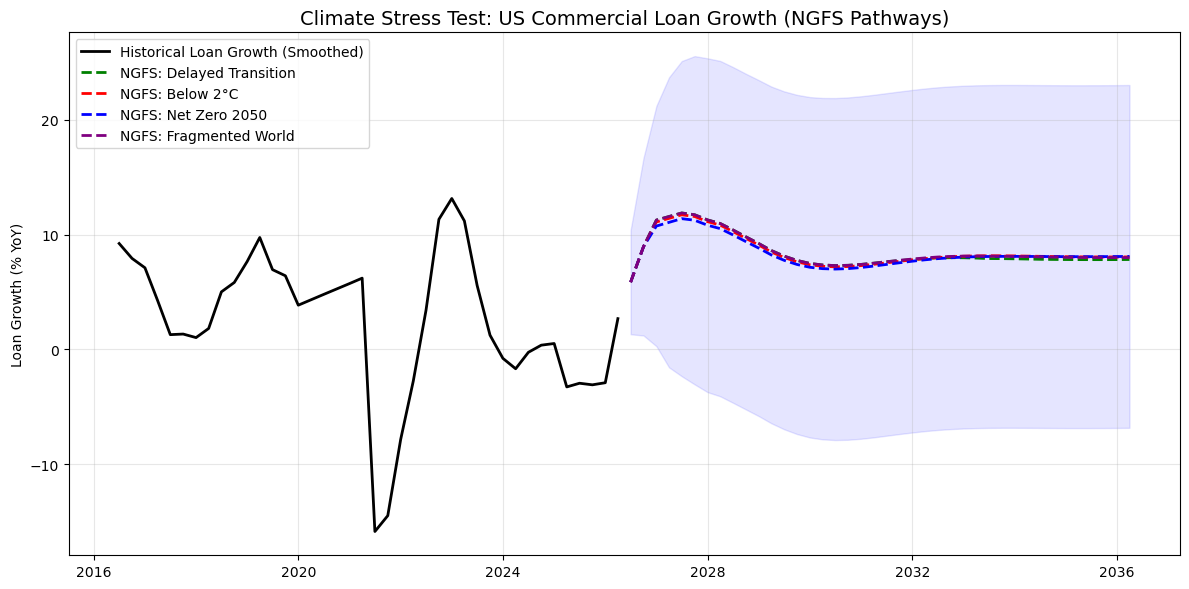

In [32]:
# geoff model 

## THIS IS THE FINAL MODEL WITH NGFS SCENARIOS INTEGRATED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear')
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# 4. Feature Engineering
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_train = df_history.dropna()

# 5. Train Model (Optimal ARIMA 2,0,2)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag2']]
model = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4)) 
model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (Updated to use actual NGFS Data)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

# NECESSARY CHANGE: Use NGFS Shocks instead of np.linspace
def build_ngfs_exog(scenario_prefix):
    # Find column
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    # Anchor to history
    future_path = last_actual_unemp + shocks
    # Combine & Lag
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
# Run all 3 scenarios through the model
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()


# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))


# Plot History
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# NGFS Scenarios
plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)
plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)
# Shading for the Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: US Commercial Loan Growth (NGFS Pathways)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##USING THIS MODEL 



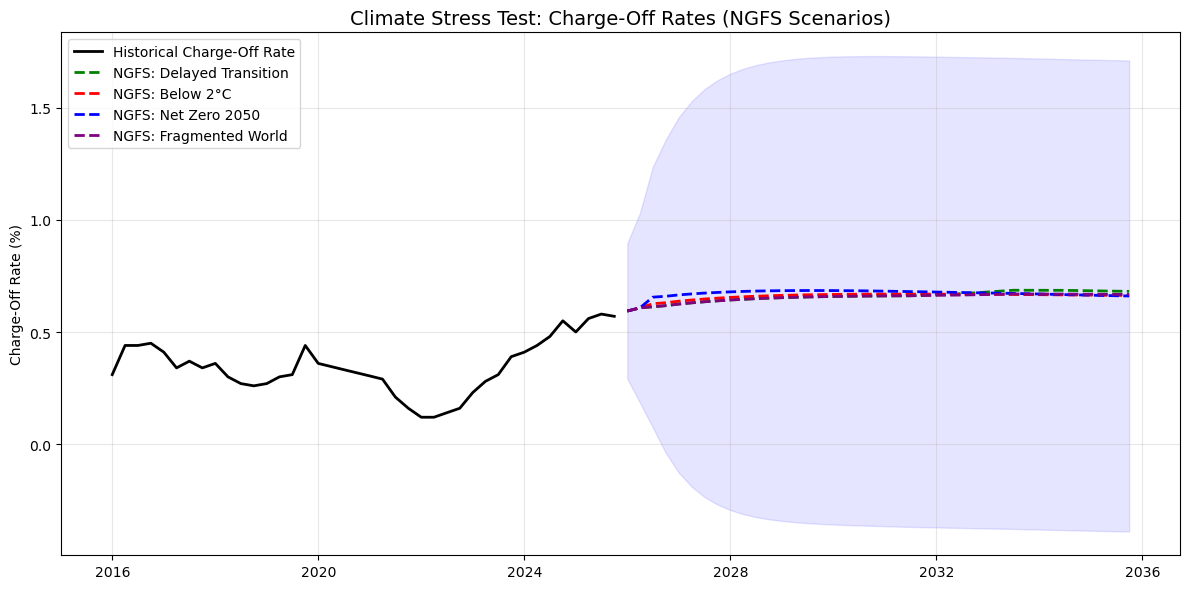

In [33]:
# geoff model 

## THIS IS THE FINAL MODEL WITH NGFS SCENARIOS INTEGRATED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

# 🔁 ONLY CHANGE: use charge-off data instead of loans
df_charge = clean_fred_data('CORBLACBS.csv', 'Charge_Off')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_charge, df_cpi, df_unemp], axis=1).dropna()

# 🔁 ONLY CHANGE: no log growth — use level directly
df_history['Charge_Off'] = df_history['Charge_Off']

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Charge_Off'] = np.nan
df_history['Charge_Off'] = df_history['Charge_Off'].interpolate(method='linear')
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# 4. Feature Engineering
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_train = df_history.dropna()

# 5. Train Model (same structure)
y = df_train['Charge_Off']
X = df_train[['Unemployment_Lag2']]

model = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4)) 
model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (UNCHANGED)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

def build_ngfs_exog(scenario_prefix):
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    future_path = last_actual_unemp + shocks
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()

# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(df_train.index[-40:], df_train['Charge_Off'][-40:], 
         label='Historical Charge-Off Rate', color='black', linewidth=2)

plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)

plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)

plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: Charge-Off Rates (NGFS Scenarios)', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ---------------------------------------------------------
# 🔍 MODEL SELECTION: FIND BEST ARIMA ORDER
# ---------------------------------------------------------

import itertools

y = df_train['Charge_Off']
X = df_train[['Unemployment_Lag2']]

# Candidate orders
p = [1, 2, 3]
d = [0]
q = [1, 2, 3]

seasonal_p = [0, 1]
seasonal_q = [0, 1]

results = []

for order in itertools.product(p, d, q):
    for seas in itertools.product(seasonal_p, [0], seasonal_q, [4]):
        try:
            model = ARIMA(y, exog=X, order=order, seasonal_order=seas)
            fit = model.fit()
            
            results.append({
                'order': order,
                'seasonal_order': seas,
                'AIC': fit.aic,
                'BIC': fit.bic
            })
            
        except:
            continue

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Sort by AIC (best model = lowest)
df_results = df_results.sort_values('AIC')

print("🔝 TOP 5 MODELS:")
print(df_results.head())

🔝 TOP 5 MODELS:
        order seasonal_order         AIC         BIC
24  (3, 0, 1)   (0, 0, 0, 4) -130.296803 -108.726973
20  (2, 0, 3)   (0, 0, 0, 4) -130.281656 -105.630421
25  (3, 0, 1)   (0, 0, 1, 4) -130.076951 -105.425716
26  (3, 0, 1)   (1, 0, 0, 4) -129.603663 -104.952428
27  (3, 0, 1)   (1, 0, 1, 4) -129.497250 -101.764610


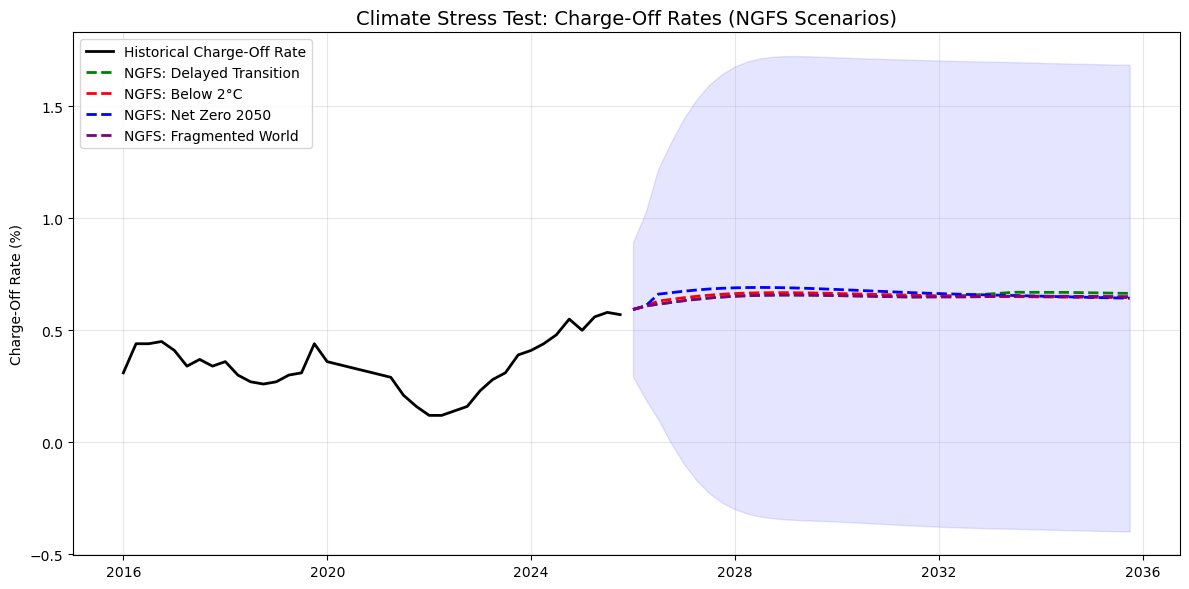

In [35]:
# using ARIMA 3,0,1



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

# 🔁 ONLY CHANGE: use charge-off data instead of loans
df_charge = clean_fred_data('CORBLACBS.csv', 'Charge_Off')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_charge, df_cpi, df_unemp], axis=1).dropna()

# 🔁 ONLY CHANGE: no log growth — use level directly
df_history['Charge_Off'] = df_history['Charge_Off']

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Charge_Off'] = np.nan
df_history['Charge_Off'] = df_history['Charge_Off'].interpolate(method='linear')
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# 4. Feature Engineering
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_train = df_history.dropna()

# 5. Train Model (BEST SPEC FROM GRID SEARCH)
y = df_train['Charge_Off']
X = df_train[['Unemployment_Lag2']]

model = ARIMA(
    y,
    exog=X,
    order=(3, 0, 1),          # ✅ BEST
    seasonal_order=(0, 0, 0, 4)  # ✅ NO SEASONAL (as selected)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (UNCHANGED)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

def build_ngfs_exog(scenario_prefix):
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    future_path = last_actual_unemp + shocks
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()

# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(df_train.index[-40:], df_train['Charge_Off'][-40:], 
         label='Historical Charge-Off Rate', color='black', linewidth=2)

plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)

plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)

plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: Charge-Off Rates (NGFS Scenarios)', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# 1. Feature Engineering: Calculate Inflation from CPI
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100

# 2. Apply the Lag (Lag 2 to match Unemployment)
df_history['Inflation_Lag2'] = df_history['Inflation'].shift(2)

# 3. Drop NaNs and define the new feature list
df_train = df_history.dropna()
features = ['Unemployment_Lag2', 'Inflation_Lag2']

# 4. Re-Train the Model with TWO exogenous variables
y = df_train['Charge_Off']
X = df_train[features]

print(f"Training SARIMAX with features: {features}")
model_multi = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4))
model_fit_multi = model_multi.fit()

print(model_fit_multi.summary())

Training SARIMAX with features: ['Unemployment_Lag2', 'Inflation_Lag2']
                                    SARIMAX Results                                     
Dep. Variable:                       Charge_Off   No. Observations:                  157
Model:             ARIMA(2, 0, 2)x(1, 0, [], 4)   Log Likelihood                  68.672
Date:                          Thu, 09 Apr 2026   AIC                           -119.345
Time:                                  10:12:29   BIC                            -91.839
Sample:                              09-30-1986   HQIC                          -108.174
                                   - 09-30-2025                                         
Covariance Type:                            opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2463      0.408     

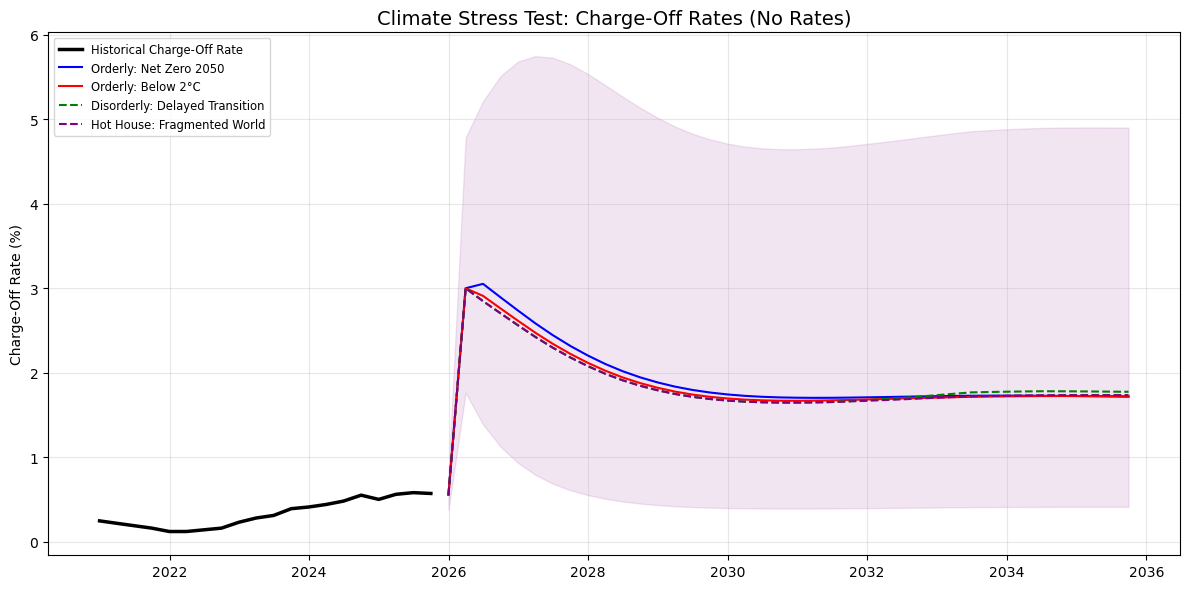

                               SARIMAX Results                                
Dep. Variable:         Log_Charge_Off   No. Observations:                  161
Model:                 ARIMA(2, 0, 3)   Log Likelihood                  43.439
Date:                Thu, 09 Apr 2026   AIC                            -68.877
Time:                        10:12:29   BIC                            -41.144
Sample:                    09-30-1985   HQIC                           -57.617
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1724      0.958     -0.180      0.857      -2.051       1.706
Unemployment_Lag2     0.1203      0.072      1.666      0.096      -0.021       0.262
GDP_Lag1          -7.131

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# ---------------------------------------------------------
# 2. LOAD DATA (REMOVED RATES)
# ---------------------------------------------------------
df_charge = clean_fred_data('CORBLACBS.csv', 'Charge_Off')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')

df_history = pd.concat([
    df_charge, df_unemp, df_gdp
], axis=1).dropna()

# ---------------------------------------------------------
# 3. SMOOTH COVID
# ---------------------------------------------------------
shock_start, shock_end = '2020-03-01', '2021-06-30'

for col in ['Charge_Off', 'Unemployment_Rate']:
    df_history.loc[shock_start:shock_end, col] = np.nan
    df_history[col] = df_history[col].interpolate(method='linear')

# ---------------------------------------------------------
# 4. LOG TRANSFORM
# ---------------------------------------------------------
epsilon = 1e-6
df_history['Charge_Off_Pos'] = df_history['Charge_Off'].clip(lower=epsilon)
df_history['Log_Charge_Off'] = np.log(df_history['Charge_Off_Pos'])

# ---------------------------------------------------------
# 5. FEATURE ENGINEERING (REMOVED RATES)
# ---------------------------------------------------------
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)

df_train = df_history.dropna()

# ---------------------------------------------------------
# 6. TRAIN MODEL (REMOVED RATES)
# ---------------------------------------------------------
y = df_train['Log_Charge_Off']
X = df_train[['Unemployment_Lag2', 'GDP_Lag1']]

model = ARIMA(
    y,
    exog=X,
    order=(2, 0, 3),
    seasonal_order=(0, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 7. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]

# ---------------------------------------------------------
# 8. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 9. BUILD EXOG (REMOVED RATES)
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):

    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_series = get_ngfs_series(scenario, "Gross Domestic Product")

    unemp_shock = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    gdp_series = gdp_series.loc[forecast_dates[0]:].head(forecast_steps)

    unemp_future = last_unemp + unemp_shock

    future = pd.DataFrame({
        'Unemployment_Rate': unemp_future.values,
        'GDP': gdp_series.values
    }, index=forecast_dates)

    full = pd.concat([df_history[['Unemployment_Rate','GDP']], future])

    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full['Unemployment_Rate'].shift(2).loc[forecast_dates]
    X_f['GDP_Lag1'] = full['GDP'].shift(1).loc[forecast_dates]

    return X_f

# ---------------------------------------------------------
# 10. RUN SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

pred_mean = {}
conf_int = {}

for key in scenarios:

    X_future = build_ngfs_exog_multi(key)
    fcst = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

    m = fcst.predicted_mean
    v = fcst.var_pred_mean
    ci_log = fcst.conf_int()

    pred_mean[key] = np.exp(m + 0.5 * v)

    ci_level = np.exp(ci_log)
    ci_level.columns = ['lower', 'upper']
    conf_int[key] = ci_level

# ---------------------------------------------------------
# 11. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Charge_Off'][-20:],
    label='Historical Charge-Off Rate',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in scenarios:
    plt.plot(
        forecast_dates,
        pred_mean[key],
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

plt.fill_between(
    forecast_dates,
    conf_int["Fragmented World"]['lower'],
    conf_int["Fragmented World"]['upper'],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: Charge-Off Rates (No Rates)', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(model_fit.summary())

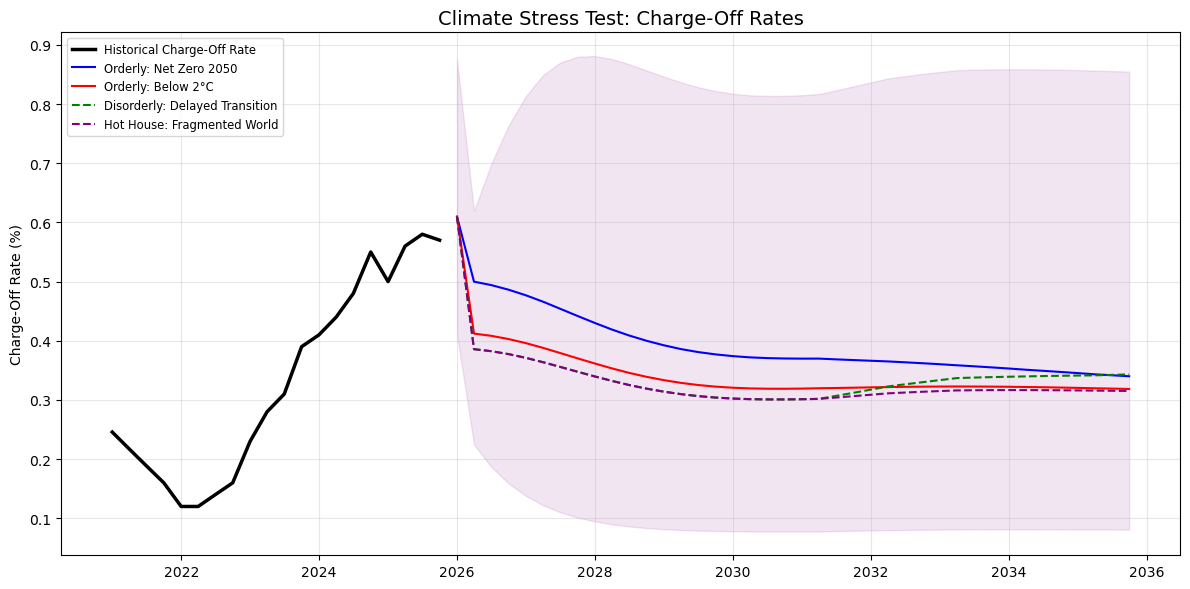

                               SARIMAX Results                                
Dep. Variable:         Log_Charge_Off   No. Observations:                  162
Model:                 ARIMA(2, 0, 3)   Log Likelihood                  40.986
Date:                Thu, 09 Apr 2026   AIC                            -61.972
Time:                        10:12:29   BIC                            -31.096
Sample:                    06-30-1985   HQIC                           -49.435
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.5480      0.995     -2.562      0.010      -4.497      -0.599
Unemployment_Lag1     0.2797      0.072      3.890      0.000       0.139       0.421
GDP_Lag1          -3.433

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# ---------------------------------------------------------
# 2. LOAD DATA (WITH RATES)
# ---------------------------------------------------------
df_charge = clean_fred_data('CORBLACBS.csv', 'Charge_Off')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

df_history = pd.concat([
    df_charge, df_unemp, df_gdp, df_rates
], axis=1).dropna()

# ---------------------------------------------------------
# 3. SMOOTH COVID
# ---------------------------------------------------------
shock_start, shock_end = '2020-03-01', '2021-06-30'

for col in ['Charge_Off', 'Unemployment_Rate']:
    df_history.loc[shock_start:shock_end, col] = np.nan
    df_history[col] = df_history[col].interpolate(method='linear')

# ---------------------------------------------------------
# 4. LOG TRANSFORM
# ---------------------------------------------------------
epsilon = 1e-6
df_history['Charge_Off_Pos'] = df_history['Charge_Off'].clip(lower=epsilon)
df_history['Log_Charge_Off'] = np.log(df_history['Charge_Off_Pos'])

# ---------------------------------------------------------
# 5. FEATURE ENGINEERING (WITH RATES)
# ---------------------------------------------------------
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)
df_history['Rates_Lag1'] = df_history['Rates'].shift(1)

df_train = df_history.dropna()

# ---------------------------------------------------------
# 6. TRAIN MODEL
# ---------------------------------------------------------
y = df_train['Log_Charge_Off']
X = df_train[['Unemployment_Lag1', 'GDP_Lag1', 'Rates_Lag1']]

model = ARIMA(
    y,
    exog=X,
    order=(2, 0, 3),
    seasonal_order=(0, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 7. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]

# ---------------------------------------------------------
# 8. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 9. BUILD EXOG (WITH RATES)
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):

    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_series = get_ngfs_series(scenario, "Gross Domestic Product")
    rate_series = get_ngfs_series(scenario, "Central bank")

    unemp_shock = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    gdp_series = gdp_series.loc[forecast_dates[0]:].head(forecast_steps)
    rate_series = rate_series.loc[forecast_dates[0]:].head(forecast_steps)

    unemp_future = last_unemp + unemp_shock

    future = pd.DataFrame({
        'Unemployment_Rate': unemp_future.values,
        'GDP': gdp_series.values,
        'Rates': rate_series.values
    }, index=forecast_dates)

    full = pd.concat([df_history[['Unemployment_Rate','GDP','Rates']], future])

    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full['Unemployment_Rate'].shift(1).loc[forecast_dates]
    X_f['GDP_Lag1'] = full['GDP'].shift(1).loc[forecast_dates]
    X_f['Rates_Lag1'] = full['Rates'].shift(1).loc[forecast_dates]

    return X_f

# ---------------------------------------------------------
# 10. RUN SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

pred_mean = {}
conf_int = {}

for key in scenarios:

    X_future = build_ngfs_exog_multi(key)
    fcst = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

    m = fcst.predicted_mean
    v = fcst.var_pred_mean
    ci_log = fcst.conf_int()

    pred_mean[key] = np.exp(m + 0.5 * v)

    ci_level = np.exp(ci_log)
    ci_level.columns = ['lower', 'upper']
    conf_int[key] = ci_level

# ---------------------------------------------------------
# 11. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Charge_Off'][-20:],
    label='Historical Charge-Off Rate',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in scenarios:
    plt.plot(
        forecast_dates,
        pred_mean[key],
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

plt.fill_between(
    forecast_dates,
    conf_int["Fragmented World"]['lower'],
    conf_int["Fragmented World"]['upper'],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: Charge-Off Rates', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(model_fit.summary())

In [39]:
from itertools import product

results = []

lags = [1, 2]
use_gdp = [True, False]
use_rates = [True, False]

for lag, gdp_flag, rate_flag in product(lags, use_gdp, use_rates):

    df_temp = df_history.copy()

    df_temp[f'Unemp_Lag{lag}'] = df_temp['Unemployment_Rate'].shift(lag)
    df_temp['GDP_Lag1'] = df_temp['GDP'].shift(1)
    df_temp['Rates_Lag1'] = df_temp['Rates'].shift(1)

    df_temp = df_temp.dropna()

    X_vars = [f'Unemp_Lag{lag}']

    if gdp_flag:
        X_vars.append('GDP_Lag1')
    if rate_flag:
        X_vars.append('Rates_Lag1')

    y = df_temp['Log_Charge_Off']
    X = df_temp[X_vars]

    try:
        model = ARIMA(y, exog=X, order=(2,0,3))
        fit = model.fit()

        results.append({
            "lag": lag,
            "GDP": gdp_flag,
            "Rates": rate_flag,
            "AIC": fit.aic
        })

    except:
        continue

results_df = pd.DataFrame(results).sort_values("AIC")
print(results_df.head(10))

   lag    GDP  Rates        AIC
3    1  False  False -80.141322
2    1  False   True -78.059712
1    1   True  False -77.598315
7    2  False  False -71.121513
6    2  False   True -69.211595
5    2   True  False -68.877116
0    1   True   True -61.971591
4    2   True   True -54.457532


In [40]:
from itertools import product
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

results = []

# Define choices
use_unemp = [True, False]
use_gdp = [True, False]
use_rates = [True, False]

lags = [1, 2]

for u_flag, g_flag, r_flag in product(use_unemp, use_gdp, use_rates):

    # Skip model with no variables at all
    if not (u_flag or g_flag or r_flag):
        continue

    for u_lag, g_lag, r_lag in product(lags, lags, lags):

        df_temp = df_history.copy()

        # Create lagged variables only if used
        X_vars = []

        if u_flag:
            col_name = f'Unemp_Lag{u_lag}'
            df_temp[col_name] = df_temp['Unemployment_Rate'].shift(u_lag)
            X_vars.append(col_name)

        if g_flag:
            col_name = f'GDP_Lag{g_lag}'
            df_temp[col_name] = df_temp['GDP'].shift(g_lag)
            X_vars.append(col_name)

        if r_flag:
            col_name = f'Rates_Lag{r_lag}'
            df_temp[col_name] = df_temp['Rates'].shift(r_lag)
            X_vars.append(col_name)

        df_temp = df_temp.dropna()

        y = df_temp['Log_Charge_Off']
        X = df_temp[X_vars]

        try:
            model = ARIMA(y, exog=X, order=(2,0,3))
            fit = model.fit()

            results.append({
                "Unemp": u_flag,
                "Unemp_Lag": u_lag if u_flag else None,
                "GDP": g_flag,
                "GDP_Lag": g_lag if g_flag else None,
                "Rates": r_flag,
                "Rates_Lag": r_lag if r_flag else None,
                "AIC": fit.aic,
                "BIC": fit.bic
            })

        except:
            continue

# Convert to dataframe
results_df = pd.DataFrame(results)

# Sort by best AIC
results_df = results_df.sort_values("AIC")

# Show top models
print("TOP 10 MODELS:")
print(results_df.head(10))

TOP 10 MODELS:
    Unemp  Unemp_Lag    GDP  GDP_Lag  Rates  Rates_Lag        AIC        BIC
19   True        1.0  False      NaN   True        2.0 -82.301421 -54.568781
17   True        1.0  False      NaN   True        2.0 -82.301421 -54.568781
27   True        1.0  False      NaN  False        NaN -80.141322 -55.440551
24   True        1.0  False      NaN  False        NaN -80.141322 -55.440551
25   True        1.0  False      NaN  False        NaN -80.141322 -55.440551
26   True        1.0  False      NaN  False        NaN -80.141322 -55.440551
16   True        1.0  False      NaN   True        1.0 -78.059712 -50.271345
18   True        1.0  False      NaN   True        1.0 -78.059712 -50.271345
8    True        1.0   True      1.0  False        NaN -77.598315 -49.809948
9    True        1.0   True      1.0  False        NaN -77.598315 -49.809948


# updates

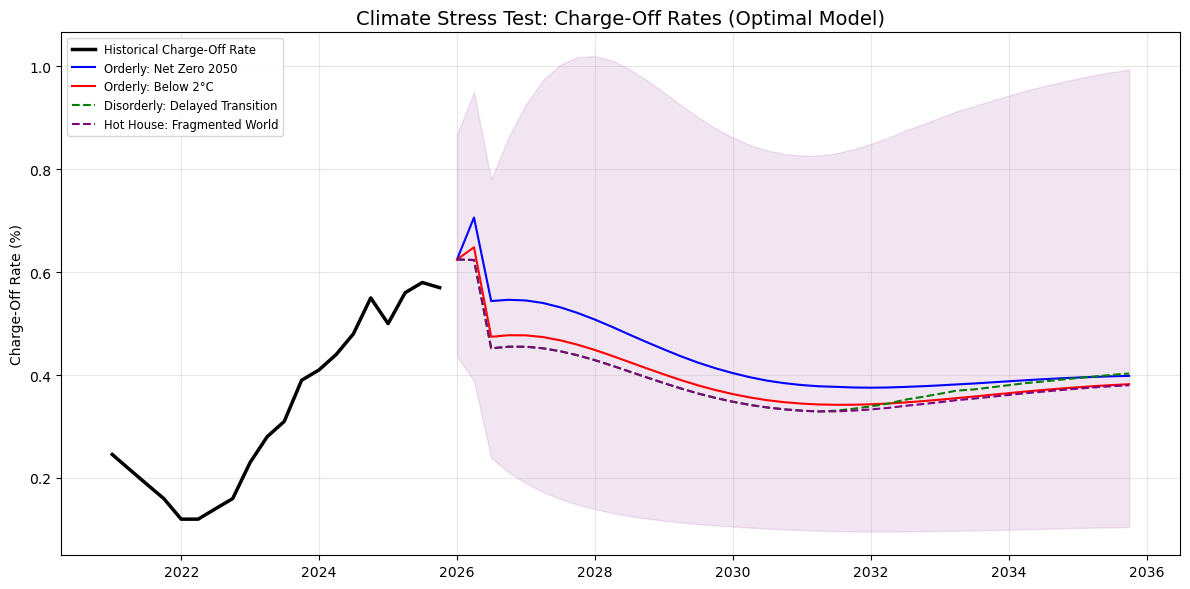

                               SARIMAX Results                                
Dep. Variable:         Log_Charge_Off   No. Observations:                  161
Model:                 ARIMA(2, 0, 3)   Log Likelihood                  50.151
Date:                Thu, 09 Apr 2026   AIC                            -82.301
Time:                        10:12:35   BIC                            -54.569
Sample:                    09-30-1985   HQIC                           -71.041
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0839      0.424     -4.920      0.000      -2.914      -1.254
Unemployment_Lag1     0.2158      0.070      3.082      0.002       0.079       0.353
Rates_Lag2            0.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
df_charge = clean_fred_data('CORBLACBS.csv', 'Charge_Off')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

df_history = pd.concat([
    df_charge, df_unemp, df_rates
], axis=1).dropna()

# ---------------------------------------------------------
# 3. SMOOTH COVID
# ---------------------------------------------------------
shock_start, shock_end = '2020-03-01', '2021-06-30'

for col in ['Charge_Off', 'Unemployment_Rate']:
    df_history.loc[shock_start:shock_end, col] = np.nan
    df_history[col] = df_history[col].interpolate(method='linear')

# ---------------------------------------------------------
# 4. LOG TRANSFORM
# ---------------------------------------------------------
epsilon = 1e-6
df_history['Charge_Off_Pos'] = df_history['Charge_Off'].clip(lower=epsilon)
df_history['Log_Charge_Off'] = np.log(df_history['Charge_Off_Pos'])

# ---------------------------------------------------------
# 5. FEATURE ENGINEERING (BEST LAGS)
# ---------------------------------------------------------
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['Rates_Lag2'] = df_history['Rates'].shift(2)

df_train = df_history.dropna()

# ---------------------------------------------------------
# 6. TRAIN MODEL
# ---------------------------------------------------------
y = df_train['Log_Charge_Off']
X = df_train[['Unemployment_Lag1', 'Rates_Lag2']]

model = ARIMA(
    y,
    exog=X,
    order=(2, 0, 3),
    seasonal_order=(0, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 7. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]
last_rates = df_history['Rates'].iloc[-1]

# ---------------------------------------------------------
# 8. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 9. BUILD EXOG (MATCH MODEL LAGS)
# ---------------------------------------------------------
def build_ngfs_exog(scenario):

    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    rate_series = get_ngfs_series(scenario, "Central bank")

    unemp_shock = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    rate_series = rate_series.loc[forecast_dates[0]:].head(forecast_steps)

    unemp_future = last_unemp + unemp_shock

    future = pd.DataFrame({
        'Unemployment_Rate': unemp_future.values,
        'Rates': rate_series.values
    }, index=forecast_dates)

    full = pd.concat([df_history[['Unemployment_Rate','Rates']], future])

    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full['Unemployment_Rate'].shift(1).loc[forecast_dates]
    X_f['Rates_Lag2'] = full['Rates'].shift(2).loc[forecast_dates]

    return X_f

# ---------------------------------------------------------
# 10. RUN SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

pred_mean = {}
conf_int = {}

for key in scenarios:

    X_future = build_ngfs_exog(key)
    fcst = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

    m = fcst.predicted_mean
    v = fcst.var_pred_mean
    ci_log = fcst.conf_int()

    pred_mean[key] = np.exp(m + 0.5 * v)

    ci_level = np.exp(ci_log)
    ci_level.columns = ['lower', 'upper']
    conf_int[key] = ci_level

# ---------------------------------------------------------
# 11. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Charge_Off'][-20:],
    label='Historical Charge-Off Rate',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in scenarios:
    plt.plot(
        forecast_dates,
        pred_mean[key],
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

plt.fill_between(
    forecast_dates,
    conf_int["Fragmented World"]['lower'],
    conf_int["Fragmented World"]['upper'],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: Charge-Off Rates (Optimal Model)', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(model_fit.summary())

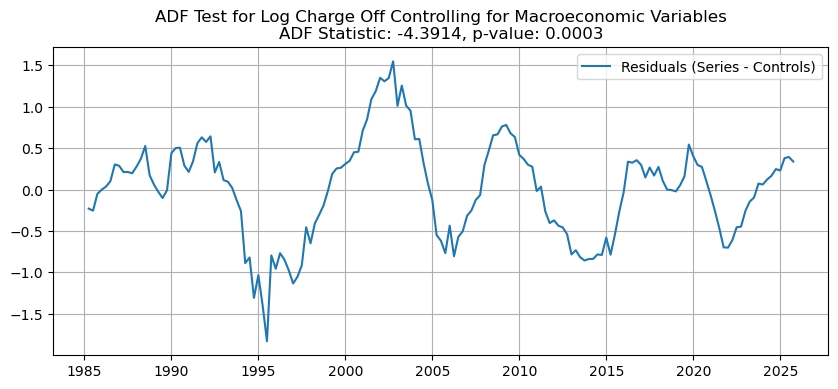

In [44]:
from statsmodels.tsa.stattools import adfuller
def plot_adf_with_controls(series, controls, title):
    # Regress series on controls and get residuals
    from statsmodels.api import OLS, add_constant
    X = add_constant(controls.dropna())
    y = series.loc[X.index]
    model = OLS(y, X).fit()
    residuals = model.resid
    
    # ADF test on residuals
    result = adfuller(residuals.dropna())
    
    plt.figure(figsize=(10, 4))
    plt.plot(residuals, label='Residuals (Series - Controls)')
    plt.title(f'{title}\nADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    plt.legend()
    plt.grid(True)
    plt.show()
controls = df_history[['Unemployment_Rate', 'Rates']]
plot_adf_with_controls(df_history['Log_Charge_Off'], controls, 'ADF Test for Log Charge Off Controlling for Macroeconomic Variables')